# 🚀 SAIR PyTorch Mastery - Lecture 5: Introduction to Sequences
## From RNN to LSTM: Teaching Machines to Understand Order

**Course:** Applied Deep Learning with PyTorch  
**Module:** Sequence & NLP  
**Instructor:** Mohammed Awad Ahmed (Silva)  
**SAIR Community:** Building Sudan's AI Future 🇸🇩

---

## 📘 Welcome to Sequences!

Today marks a fundamental shift in your deep learning journey. You've mastered how neural networks understand **space** (images with CNNs). Now you'll learn how they understand **time** and **order** with sequences.

### Where You Are in Your Journey

```
Module 1: PyTorch Fundamentals → Tensors, autograd, training loops
Module 2: Vision & CNNs → Spatial reasoning with images
Module 3: Sequence & NLP (YOU ARE HERE)
    ├── Lecture 6: Introduction to Sequences (Today)
    ├── Lecture 7: Many-to-Many (Translation, Generation)
    ├── Lecture 8A: HuggingFace Ecosystem (Pretrained Models)
    └── Lecture 8B: Fine-tuning (Make It Yours)
```

### What You'll Master Today

**NLP Fundamentals:**
- ✅ Convert raw text into numerical representations
- ✅ Build vocabulary with special tokens
- ✅ Understand word embeddings vs one-hot encoding
- ✅ Handle out-of-vocabulary (OOV) words

**Sequence Modeling:**
- ✅ Explain why order matters in any sequential data
- ✅ Identify many-to-one problems in the wild
- ✅ Understand limitations of feedforward/CNN approaches

**RNN Architecture:**
- ✅ Implement an RNN cell from scratch
- ✅ Visualize hidden state as "memory through time"
- ✅ Understand the vanishing gradient problem mathematically
- ✅ Compare RNN vs LSTM on real data

**Practical Implementation:**
- ✅ Build complete training pipelines for RNN and LSTM
- ✅ Train models on real IMDB data
- ✅ Compare performance metrics
- ✅ Analyze predictions and errors

**Real-World Application:**
- ✅ Identify sequence problems in Sudan's challenges

### How to Use This Notebook

This is a **standalone teaching notebook**. To get the most from it:

1. **Read every markdown cell carefully** - they contain the concepts and mental models
2. **Run every code cell sequentially** - each builds on the previous
3. **Pause at 🛑 STOP & THINK prompts** - predict what will happen before running
4. **Experiment with parameters** - change values and observe what happens
5. **Complete the ✅ Mastery Check** at the end

**Time Commitment:** 3-4 hours for deep understanding

---

In [ ]:
# ⚙️ Initial Setup - Run this first
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter
import re
import warnings
import zipfileA
import requests
from pathlib import Path
import time
warnings.filterwarnings('ignore')

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ Imports loaded successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create data directory
Path("../data/imdb").mkdir(parents=True, exist_ok=True)

✅ Imports loaded successfully!
PyTorch version: 2.10.0+cu128
GPU available: True
Using device: cuda


# 🎯 PART 0: What Are Sequences and Why Should You Care?

Before we dive into code, let's build intuition about what sequences are and why they're everywhere in AI.

## The Universal Language of Order

Think about your day today. Did things happen in a specific order?

```
Your morning routine:
Wake up → Shower → Breakfast → Commute → Work
```

What would happen if you reversed this order? Try commuting before waking up! The **order matters** because each step depends on what came before.

Language works the same way:

```
"I loved this movie" → Positive sentiment
"I hated this movie" → Negative sentiment
```

Same words (I, this, movie) but different order of 'loved' vs 'hated' completely changes the meaning!

## Sequences Are Everywhere in AI

Let's look at the vast world of sequential data:

```
📝 TEXT (what we'll focus on today)
   - Sentences: sequences of words
   - Documents: sequences of paragraphs
   - Code: sequences of tokens

📈 TIME SERIES
   - Stock prices: sequences of daily values
   - Weather data: sequences of hourly readings
   - Sensor data: sequences of measurements

🎵 AUDIO
   - Speech: sequences of sound waves
   - Music: sequences of notes
   - Bird calls: sequences of frequencies

🎬 VIDEO
   - Movies: sequences of frames
   - Action recognition: sequences of poses
   - Security footage: sequences of events

🧬 BIOLOGICAL DATA
   - DNA: sequences of nucleotides (A,T,G,C)
   - Protein sequences: sequences of amino acids
   - ECG: sequences of heart electrical activity
```

## 🧠 Mental Model: The Recipe vs. The Ingredient List

Here's the key insight that will guide everything you learn today:

```
INGREDIENTS (Bag of words - what CNNs would see):
{flour, eggs, sugar, butter, chocolate}

These ingredients could make COOKIES or CAKE or BROWNIES!
The ingredients alone don't tell you the final dish.

RECIPE (Sequence - what RNNs understand):
1. Cream butter and sugar
2. Add eggs one at a time
3. Fold in flour
4. Add chocolate chips
5. Bake at 350°F

Now you know it's COOKIES! The ORDER of steps determines the result.
```

This is why we need specialized architectures for sequences. A bag-of-words approach (like treating text as a set) loses the most important information: **the order**.

### 🛑 STOP & THINK

Think of 3 real-world examples where order matters. Write them down now:

1. Example from your daily life: _________________________________
2. Example from your field of study: _________________________________
3. Example from Sudan/Sudanese context: _________________________________

**Keep these in mind - we'll come back to them at the end of the lecture!**

# 🔗 PART 1: Connecting to Your Journey (From CNNs to Sequences)

Now let's connect this new world of sequences to what you already know from CNN Module.

## What You Already Know: CNNs for Spatial Reasoning

In the previous module, you mastered Convolutional Neural Networks. Let's recall how they work:

```
CNN for Image Classification:
        
    [Image] 
    (224×224×3 grid of pixels)
        ↓
    [Convolutional Layers]
    (Learn spatial hierarchies)
        ↓
    Edge detectors → Texture detectors → Part detectors → Object detectors
        ↓
    [Fully Connected Layers]
        ↓
    [Class: "Cat" or "Dog"]
```

**Key assumptions CNNs make:**
- Input has fixed size (we resize all images to 224×224)
- Spatial locality matters (nearby pixels are related)
- The 2D grid structure is fixed and meaningful

## Today's Leap: From Space to Time

Now we tackle **temporal reasoning** with RNNs:

```
RNN for Sentiment Analysis:
        
    ["I", "loved", "this", "movie"] 
    (Variable length sequence - could be 4 words or 400!)
        ↓
    [Recurrent Layers]
    (Learn temporal dependencies)
        ↓
    Word₁ → Word₂ → Word₃ → Word₄ → ...
      ↓       ↓       ↓       ↓
     h₁  →   h₂  →   h₃  →   h₄  (memory builds over time)
        ↓
    [Last Hidden State] (contains summary of entire sequence)
        ↓
    [Sentiment: "Positive"]
```

**Key RNN assumptions:**
- Input has variable length (no resizing needed!)
- Temporal order matters critically
- **Permuting the sequence changes meaning entirely**

## The Fundamental Shift in Thinking

Let's compare side-by-side so you see the evolution:

| Aspect | CNN (You Know) | RNN (Today) |
|--------|----------------|-------------|
| **Input Structure** | Fixed-size grid (e.g., 224×224) | Variable-length sequence (any length!) |
| **Parameter Sharing** | Across space (same conv filter slides over image) | Across time (same RNN cell processes each word) |
| **Memory** | None (each prediction independent) | Hidden state carries context forward |
| **Receptive Field** | Local (kernel size limits view) | Global (can see entire sequence through hidden state) |
| **Order Sensitivity** | Fixed spatial structure | Temporal order is everything |

## 🧠 Mental Model: The Scanner vs. The Reader

This is the most important intuition for today:

```
CNN is like a SCANNER:
    "I see the whole image at once. I process all patches independently,
     but I know their spatial arrangement from the grid structure."

RNN is like a READER:
    "I read word by word. I remember what I've read so far. 
     My understanding evolves with each new word.
     By the end, I have a complete understanding of the whole text."
```

This difference - processing all at once vs. building understanding over time - is why RNNs are fundamentally different from anything you've learned before.

# 🎯 PART 2: The Many-to-One Architecture Pattern

Now let's get specific about the architecture we're building today. The title says "Many-to-One" - what does that mean?

## Visualizing the Flow

Here's the pattern we'll implement:

```
Time:    t=1      t=2      t=3      ...      t=n
        [x₁] ──→ [x₂] ──→ [x₃] ──→ ... ──→ [xₙ]    (MANY inputs)
         ↓        ↓        ↓                 ↓
        [h₁] ──→ [h₂] ──→ [h₃] ──→ ... ──→ [hₙ]    (hidden states)
                                              ↓
                                           [y]       (ONE output)
```

**MANY inputs → ONE output**

This is the pattern for any task where you need to make a single decision based on a sequence of observations.

## Real-World Many-to-One Problems

Let's make this concrete with examples you'll encounter:

### 📝 **Text Classification**
```
Input: ["This", "movie", "is", "absolutely", "fantastic"] (5 words)
Output: [Positive] (1 sentiment)

Why? You read the whole review, then decide if it's positive or negative.
```

### 📈 **Time Series Prediction**
```
Input: [Q1_sales, Q2_sales, Q3_sales, Q4_sales] (4 quarters)
Output: [Next_year_trend] (1 prediction)

Why? You look at the whole year's pattern to forecast next year.
```

### 🏥 **Medical Diagnosis**
```
Input: [Day1_symptoms, Day2_symptoms, ..., Day7_symptoms] (7 days)
Output: [Diagnosis] (1 condition)

Why? You track how symptoms evolve over a week to make a diagnosis.
```

### 💰 **Fraud Detection**
```
Input: [txn₁, txn₂, txn₃, ..., txnₙ] (sequence of transactions)
Output: [Fraud Probability] (1 risk score)

Why? You analyze spending patterns to detect anomalies.
```

### 🌾 **Agricultural Monitoring (Sudanese Context)**
```
Input: [Week1_rainfall, Week2_rainfall, ..., Week12_rainfall] (12 weeks)
Output: [Drought Risk] (1 warning level)

Why? You need the full rainy season pattern to assess drought risk.
```

## The Three Sequence Patterns

To give you context for the whole module, here are all three patterns:

```
MANY-TO-ONE (Today):              MANY-TO-MANY (Next Lecture):
[x₁, x₂, x₃] → [y]                [x₁, x₂, x₃] → [y₁, y₂, y₃]
Classification                    Translation/Tagging

ONE-TO-MANY (Image Captioning):
[x] → [y₁, y₂, y₃]
Image → Description
```

### 🛑 STOP & THINK

For each scenario below, identify the pattern (many-to-one, many-to-many, or one-to-many):

1. Predicting tomorrow's weather from 30 days of historical data → _______
2. Generating a paragraph describing a photo → _______
3. Translating English to Arabic → _______
4. Detecting if a heart ECG reading shows arrhythmia → _______
5. Converting speech audio to text transcript → _______
6. Classifying a movie review as positive/negative → _______

**Answers at the end of the notebook.**

# 📝 PART 3: Text → Numbers (The Foundation of NLP)

Now we begin our practical journey. Our goal: convert raw text into numbers that neural networks can process.

## The Core Challenge

Neural networks understand **numbers**, not words. They operate on tensors of floating-point values. So our first task is:

```
"The movie was fantastic!" → [45, 23, 67, 89, 12, 345] → [0.2, 0.8, -0.3, ...]
         Raw text                      IDs                      Embeddings
```

This transformation happens in three steps:
1. **Tokenization**: Split text into pieces (words, subwords, or characters)
2. **Numericalization**: Map each piece to a unique ID
3. **Embedding**: Convert IDs to dense vectors that capture meaning

## Step 1: Tokenization (Splitting Text into Pieces)

First decision: How should we split the text? Different levels capture different information:

```python
text = "I loved this movie, it was fantastic!"

# Word-level tokens (what we'll use today)
word_tokens = ["I", "loved", "this", "movie", ",", "it", "was", "fantastic", "!"]
# Pros: Intuitive, preserves word meanings
# Cons: Large vocabulary (50k+), OOV problems

# Character-level tokens
char_tokens = ["I", " ", "l", "o", "v", "e", "d", " ", "t", "h", "i", "s", ...]
# Pros: Tiny vocabulary (~100), no OOV
# Cons: Very long sequences, loses word-level meaning

# Subword-level tokens (BPE - modern approach)
subword_tokens = ["I", "lov", "ed", "this", "movie", ",", "it", "was", "fant", "astic", "!"]
# Pros: Best of both worlds! Common subwords, handles OOV
# Cons: More complex to implement
```

For this lecture, we'll use **word-level** tokenization because it's easier to understand the concepts. In production, you'd use subword tokenization (like BPE or WordPiece).

## Step 2: Building a Vocabulary

Once we have tokens, we need to build a mapping from tokens to numbers. This is called a **vocabulary**.

### Special Tokens

Every vocabulary needs two special tokens:

```
<PAD>: 0  - Padding token. Makes all sequences same length in a batch.
<UNK>: 1  - Unknown token. For words not in vocabulary.
```

### The Min-Frequency Trick

We don't want to include every word we see. Why? If a word appears only once in the entire dataset, the model can't learn a meaningful representation for it. It's better to map it to <UNK> and let the model learn a general "unknown word" representation.

Let's build our vocabulary class:

In [ ]:
class Vocabulary:
    """Build vocabulary from text data
    
    This class handles the mapping between words and indices.
    It's a fundamental building block for any NLP project.
    """
    def __init__(self, min_freq=5):
        # Special tokens get indices 0 and 1
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.min_freq = min_freq
        self.word_counts = {}
    
    def build_vocab(self, texts):
        """Build vocabulary from list of texts"""
        print("Building vocabulary...")
        
        # First pass: count all words
        for text in texts:
            # Simple tokenization - split on whitespace
            for word in text.lower().split():
                # Remove punctuation for cleaner vocabulary
                word = re.sub(r'[^\w\s]', '', word)
                if word:  # Skip empty strings
                    self.word_counts[word] = self.word_counts.get(word, 0) + 1
        
        print(f"  Found {len(self.word_counts):,} unique words")
        
        # Second pass: add words that meet minimum frequency
        words_added = 0
        for word, count in self.word_counts.items():
            if count >= self.min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                words_added += 1
        
        print(f"  Words meeting min_freq={self.min_freq}: {words_added:,}")
        print(f"  Words discarded (rare): {len(self.word_counts) - words_added:,}")
        
        # Calculate coverage - what % of words in text are in vocabulary?
        total_words = sum(self.word_counts.values())
        covered_words = sum(count for word, count in self.word_counts.items() 
                           if word in self.word2idx)
        coverage = covered_words / total_words * 100
        print(f"  Coverage of training text: {coverage:.1f}%")
        
        return self
    
    def encode(self, text):
        """Convert text to list of indices"""
        tokens = []
        for word in text.lower().split():
            word = re.sub(r'[^\w\s]', '', word)
            if word:  # Skip empty strings
                idx = self.word2idx.get(word, self.word2idx['<UNK>'])
                tokens.append(idx)
        return tokens
    
    def decode(self, indices):
        """Convert indices back to text (for debugging)"""
        words = []
        for idx in indices:
            word = self.idx2word.get(idx, '<UNK>')
            words.append(word)
        return ' '.join(words)

# Let's test it with some sample data
sample_texts = [
    "I loved this movie it was fantastic",
    "This film was terrible I hated it",
    "Amazing acting and great story",
    "Boring and predictable waste of time",
    "One of the best movies I've ever seen",
    "Worst film of the year complete garbage"
] * 50  # Repeat to simulate more data

vocab = Vocabulary(min_freq=2).build_vocab(sample_texts)
print(f"\n📊 Final vocabulary size: {len(vocab.word2idx)}")

Building vocabulary...
  Found 31 unique words
  Words meeting min_freq=2: 31
  Words discarded (rare): 0
  Coverage of training text: 100.0%

📊 Final vocabulary size: 33


### 🧠 Mental Model: The Phonebook

Think of your vocabulary as a phonebook:

```
<PAD>  → 0  (reserved - like a blank line in the phonebook)
<UNK>  → 1  (unknown - like "number not found")
the    → 2  (common word - everyone has this number)
movie  → 3
loved  → 4
film   → 5
...
cinematography → <UNK> (rare word - not in our phonebook)
```

Every word gets a unique number. Unknown words all share the same <UNK> number.

## Step 3: The OOV (Out-of-Vocabulary) Problem

Now let's see what happens with words our vocabulary hasn't seen. This is a fundamental limitation of word-level tokenization.

In [ ]:
print("="*60)
print("THE OOV PROBLEM DEMONSTRATION")
print("="*60)

test_words = [
    "cinematography",  # Common in reviews but might be rare
    "masterpiece",     # Common positive word
    "abysmal",         # Common negative word
    "xylophone",       # Rare, likely OOV
    "quintessentially",# Rare, likely OOV
    "the",             # Very common, should be in vocab
    "movie",           # Very common, should be in vocab
    "fantastic",       # Should be in vocab from our samples
    "terrible"         # Should be in vocab from our samples
]

print("\n🔍 Testing vocabulary coverage:")
print("-" * 60)
for word in test_words:
    indices = vocab.encode(word)
    idx = indices[0] if indices else vocab.word2idx['<UNK>']
    status = "✅ IN vocabulary" if idx != 1 else "❌ OOV (unknown)"
    print(f"  '{word}': index {idx} - {status}")

print("\n⚠️ The OOV Problem:")
print("  • Common words like 'cinematography' might be missing")
print("  • Rare but meaningful words become <UNK>")
print("  • We lose information!")
print("\n💡 This is why modern NLP uses subword tokenization (BPE):")
print("   'cinematography' → ['cine', 'mat', 'ography'] (all known pieces!)")

THE OOV PROBLEM DEMONSTRATION

🔍 Testing vocabulary coverage:
------------------------------------------------------------
  'cinematography': index 1 - ❌ OOV (unknown)
  'masterpiece': index 1 - ❌ OOV (unknown)
  'abysmal': index 1 - ❌ OOV (unknown)
  'xylophone': index 1 - ❌ OOV (unknown)
  'quintessentially': index 1 - ❌ OOV (unknown)
  'the': index 23 - ✅ IN vocabulary
  'movie': index 5 - ✅ IN vocabulary
  'fantastic': index 8 - ✅ IN vocabulary
  'terrible': index 10 - ✅ IN vocabulary

⚠️ The OOV Problem:
  • Common words like 'cinematography' might be missing
  • Rare but meaningful words become <UNK>
  • We lose information!

💡 This is why modern NLP uses subword tokenization (BPE):
   'cinematography' → ['cine', 'mat', 'ography'] (all known pieces!)


## Step 4: Why Subword Tokenization?

Let's preview the solution that modern NLP uses:

```
Byte-Pair Encoding (BPE) Algorithm:
1. Start with characters: c i n e m a t o g r a p h y
2. Count frequency of adjacent pairs: 'c i' appears 1 time, 'i n' 1 time, etc.
3. Find most frequent pair: 'a' + 't' appears 2 times → merge to 'at'
4. New text: c i n e m at o g r a p h y
5. Repeat: find most frequent pair now: 'ph' + 'y' → 'phy'
6. Continue until vocabulary reaches desired size (e.g., 30,000)

Final vocabulary contains common subwords:
['the', 'ing', 'tion', 'pre', 'ing', 'ed', 'ly', 'cine', 'mat', 'ography', ...]

Now "cinematography" = ["cine", "mat", "ography"] (all in vocabulary!)
"unprecedentedly" = ["un", "pre", "cedent", "ly"] (all known!)
```

This is why models like BERT and GPT can handle any word - they break unknown words into known pieces!

### 🛑 STOP & THINK

Experiment with the `min_freq` parameter:

```python
# Try different min_freq values
for min_freq in [1, 2, 5, 10]:
    vocab_test = Vocabulary(min_freq=min_freq).build_vocab(sample_texts)
    print(f"min_freq={min_freq}: vocab_size={len(vocab_test.word2idx)}")
```

**Questions to think about:**
- What happens to vocabulary size as min_freq increases?
- What happens to coverage of rare words?
- What's the trade-off between vocabulary size and information loss?
- If you set min_freq=1, what problem might occur with very rare words?

Run the code below to see:

In [ ]:
print("\n📊 Effect of min_freq on vocabulary size:")
print("-" * 50)
for min_freq in [1, 2, 5, 10]:
    vocab_test = Vocabulary(min_freq=min_freq).build_vocab(sample_texts)
    print(f"min_freq={min_freq}: vocab_size={len(vocab_test.word2idx):,}")
    print()


📊 Effect of min_freq on vocabulary size:
--------------------------------------------------
Building vocabulary...
  Found 31 unique words
  Words meeting min_freq=1: 31
  Words discarded (rare): 0
  Coverage of training text: 100.0%
min_freq=1: vocab_size=33

Building vocabulary...
  Found 31 unique words
  Words meeting min_freq=2: 31
  Words discarded (rare): 0
  Coverage of training text: 100.0%
min_freq=2: vocab_size=33

Building vocabulary...
  Found 31 unique words
  Words meeting min_freq=5: 31
  Words discarded (rare): 0
  Coverage of training text: 100.0%
min_freq=5: vocab_size=33

Building vocabulary...
  Found 31 unique words
  Words meeting min_freq=10: 31
  Words discarded (rare): 0
  Coverage of training text: 100.0%
min_freq=10: vocab_size=33



# 🎨 PART 4: Numbers → Meaning (Word Embeddings)

We've converted words to IDs, but there's a fundamental problem with using raw IDs:

## The Problem with IDs

```
Word:      "good" → ID: 45
           "great" → ID: 67
           "excellent" → ID: 89
           "bad" → ID: 123

The numbers 45, 67, 89, and 123 are just arbitrary indices!
The model doesn't know that:
- "good", "great", and "excellent" are SIMILAR in meaning
- They are all OPPOSITE of "bad"
- "movie" and "film" are synonyms
```

## One-Hot Encoding (The Wrong Way)

One naive approach is one-hot encoding:

```
One-hot vectors (simplified vocabulary of 10,000 words):
"good"     → [0,0,0,...,1,0,0,...]  (1 at position 45)
"great"    → [0,0,0,...,1,0,0,...]  (1 at position 67)
"bad"      → [0,0,0,...,1,0,0,...]  (1 at position 123)

Problems:
1. All vectors are orthogonal (dot product = 0 between any two)
2. No notion of similarity - "good" and "great" are as different as "good" and "bad"
3. Extremely high-dimensional (10,000 dimensions!)
4. Computationally wasteful (mostly zeros)
```

## Embeddings: The Solution

> **Embeddings are dense vectors where similar words are close in vector space**

Instead of a 10,000-dimensional sparse vector, we use a dense vector of, say, 300 dimensions. Each dimension learns to represent some aspect of meaning.

```
Embedding space (simplified to 2D for visualization):

        ↑ Sentiment
        │
  0.8   │     good ●  ● great
        │         ● excellent
  0.4   │
        │                    ● movie
  0.0   │                           ● film
        │
 -0.4   │     bad ●  ● terrible
        │         ● awful
 -0.8   │
        └──────────────────────────────→ Intensity
            -0.8  -0.4  0.0  0.4  0.8

"good", "great", "excellent" cluster together (all positive)
"bad", "terrible", "awful" cluster together (all negative)
"movie" and "film" cluster together (synonyms)
```

### 🧠 Mental Model: The Semantic Map

Imagine a 3D space where each dimension captures a aspect of meaning:

```
Dimension 1: Positive/Negative sentiment
Dimension 2: Intensity (strong/mild) 
Dimension 3: Formality (formal/casual)

"good"     → (0.7, 0.3, 0.2)
"great"    → (0.8, 0.8, 0.2)  ← close to "good" (same sentiment, higher intensity)
"bad"      → (-0.7, 0.3, 0.2) ← far from "good" (opposite sentiment)
"excellent" → (0.9, 0.9, 0.3) ← close to "great"
"awesome"  → (0.8, 0.7, -0.2) ← close to "great" but more casual

Words with similar meanings live in the same neighborhood!
```

## Embeddings vs. Conv Filters (Connection to Module 2)

Remember how CNNs learn hierarchical features? Embeddings are analogous:

```python
# In CNNs (what you already know):
conv_filter = nn.Conv2d(3, 64, kernel_size=3)
# Learns: edge detectors → texture detectors → pattern detectors → object parts

# In NLP (what you're learning):
embedding = nn.Embedding(vocab_size, embedding_dim)
# Learns: semantic features, syntactic features, sentiment dimensions
```

**Both are learned representations:**
- Conv filters: Learn **spatial** features from pixel patterns
- Embeddings: Learn **semantic** features from word co-occurrence patterns

## Understanding PyTorch Embeddings

Let's see how embeddings work in practice:

In [ ]:
print("="*60)
print("UNDERSTANDING EMBEDDINGS")
print("="*60)

# Create a simple embedding layer
vocab_size = 10  # Small vocabulary for demonstration
embedding_dim = 5  # Small dimension so we can see the numbers
embedding = nn.Embedding(vocab_size, embedding_dim)

print(f"Embedding layer: {vocab_size} words × {embedding_dim} dimensions")
print(f"Weight matrix shape: {embedding.weight.shape}")
print(f"Total parameters: {vocab_size * embedding_dim} learnable numbers")
print("\nEmbedding weights (randomly initialized):")
print(embedding.weight.data)

# Look up embeddings for specific words
word_indices = torch.tensor([2, 5, 2])  # Look up words 2, 5, and 2 again
word_vectors = embedding(word_indices)

print(f"\nLooking up indices {word_indices.tolist()}:")
print(f"Output shape: {word_vectors.shape}")
print("Word vectors:")
print(word_vectors)
print("\nNote: Same index (2) gives SAME vector - that's the lookup table!")

UNDERSTANDING EMBEDDINGS
Embedding layer: 10 words × 5 dimensions
Weight matrix shape: torch.Size([10, 5])
Total parameters: 50 learnable numbers

Embedding weights (randomly initialized):
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784],
        [-1.2345, -0.0431, -1.6047, -0.7521,  1.6487],
        [-0.3925, -1.4036, -0.7279, -0.5594, -0.7688],
        [ 0.7624,  1.6423, -0.1596, -0.4974,  0.4396],
        [-0.7581,  1.0783,  0.8008,  1.6806,  1.2791],
        [ 1.2964,  0.6105,  1.3347, -0.2316,  0.0418],
        [-0.2516,  0.8599, -1.3847, -0.8712,  0.0780],
        [ 0.5258, -0.4880,  1.1914, -0.8140, -0.7360],
        [-0.8371, -0.9224, -0.0635,  0.6756, -0.0978],
        [ 1.8446, -1.1845,  1.3835, -1.2024,  0.7078]])

Looking up indices [2, 5, 2]:
Output shape: torch.Size([3, 5])
Word vectors:
tensor([[-0.3925, -1.4036, -0.7279, -0.5594, -0.7688],
        [ 1.2964,  0.6105,  1.3347, -0.2316,  0.0418],
        [-0.3925, -1.4036, -0.7279, -0.5594, -0.7688]],
       grad_fn=<

## Visualizing the Embedding Space

Now let's visualize what embeddings look like. Initially, they're random - similar words are NOT necessarily close. But during training, they'll organize themselves.

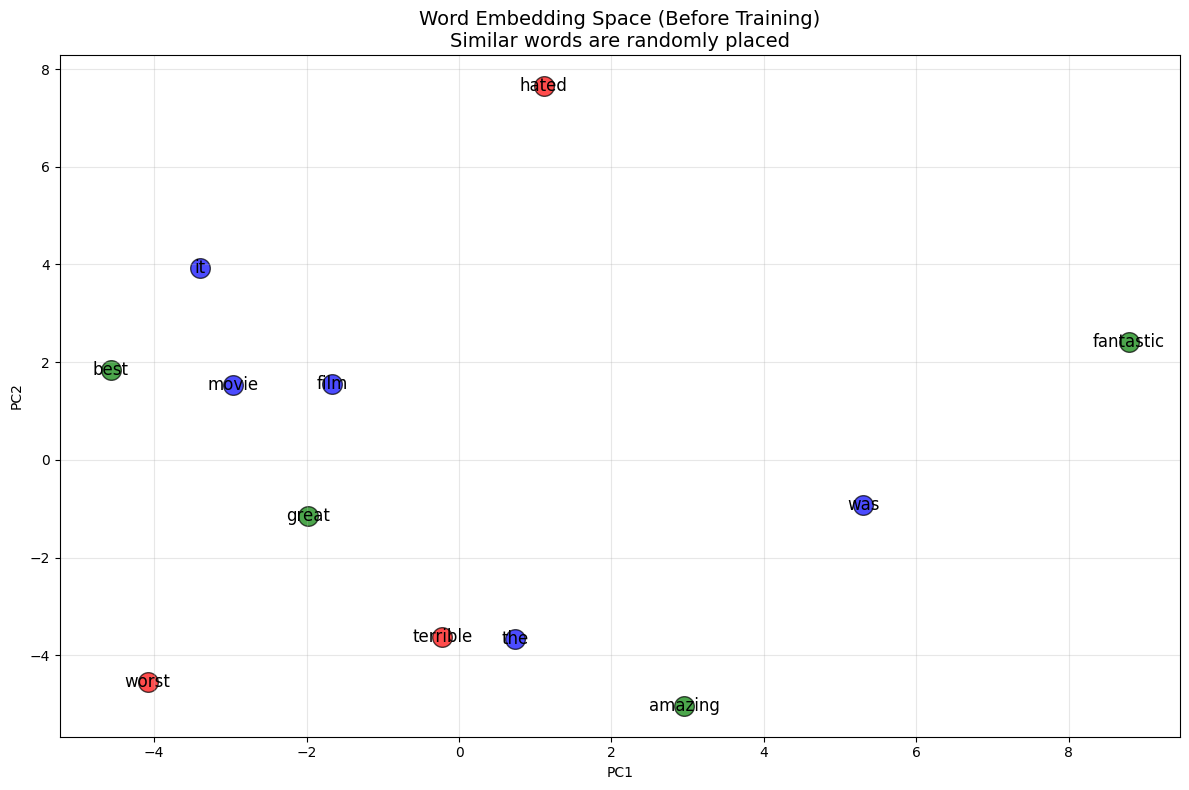


🎯 Key Insight:
   • Initially, embeddings are RANDOM
   • Similar words are NOT necessarily close
   • During training, the model will learn to push
     similar words together and different words apart!

✅ Was your prediction correct? The words are randomly scattered!


In [ ]:
def visualize_embedding_space(emb_layer, words, word2idx):
    """Visualize that similar words should cluster together"""
    from sklearn.decomposition import PCA
    
    # Get embeddings for available words
    indices = []
    available_words = []
    for word in words:
        if word in word2idx:
            indices.append(word2idx[word])
            available_words.append(word)
    
    if not indices:
        print("No words found in vocabulary")
        return
    
    # Get embeddings
    embeddings = emb_layer(torch.tensor(indices)).detach().numpy()
    
    # Reduce to 2D for visualization
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    # Plot
    plt.figure(figsize=(12, 8))
    
    # Define word groups for coloring
    positive_words = ['good', 'great', 'excellent', 'fantastic', 'amazing', 'wonderful', 'best', 'loved']
    negative_words = ['bad', 'terrible', 'awful', 'horrible', 'worst', 'hated', 'garbage']
    neutral_words = ['movie', 'film', 'the', 'was', 'it', 'this']
    
    # Color by sentiment group
    for i, word in enumerate(available_words):
        if word in positive_words:
            color = 'green'
        elif word in negative_words:
            color = 'red'
        else:
            color = 'blue'
        
        plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], 
                   c=color, s=200, alpha=0.7, edgecolors='black')
        plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                    fontsize=12, ha='center', va='center')
    
    plt.title("Word Embedding Space (Before Training)\nSimilar words are randomly placed", 
              fontsize=14)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n🎯 Key Insight:")
    print("   • Initially, embeddings are RANDOM")
    print("   • Similar words are NOT necessarily close")
    print("   • During training, the model will learn to push")
    print("     similar words together and different words apart!")
    
# Test with random embeddings
test_words = ['good', 'great', 'excellent', 'best', 'fantastic', 'amazing',
              'bad', 'terrible', 'awful', 'worst', 'hated',
              'movie', 'film', 'the', 'was', 'it']

# Create a larger embedding layer for visualization
emb_layer = nn.Embedding(len(vocab.word2idx), 128)
visualize_embedding_space(emb_layer, test_words, vocab.word2idx)

print("\n✅ Was your prediction correct? The words are randomly scattered!")

### 🛑 STOP & THINK

Before moving on, let's calculate something practical:

```
If vocab_size = 10,000 and embedding_dim = 300:
- How many parameters in the embedding layer?
- How much memory do these parameters use (in MB)?
```

**Calculate, then run the code below:**

In [ ]:
vocab_size = 10000
embed_dim = 300
params = vocab_size * embed_dim
memory_mb = params * 4 / (1024 * 1024)  # 4 bytes per float32

print(f"Embedding parameters: {params:,}")
print(f"Memory for embeddings: {memory_mb:.1f} MB")
print(f"\n💡 During training, you need ~4x this memory:")
print(f"   • Parameters: {memory_mb:.1f} MB")
print(f"   • Gradients: {memory_mb:.1f} MB")
print(f"   • Optimizer states (Adam): {memory_mb*2:.1f} MB")
print(f"   • Total: ~{memory_mb*4:.1f} MB")

Embedding parameters: 3,000,000
Memory for embeddings: 11.4 MB

💡 During training, you need ~4x this memory:
   • Parameters: 11.4 MB
   • Gradients: 11.4 MB
   • Optimizer states (Adam): 22.9 MB
   • Total: ~45.8 MB


# 🔧 PART 5: Building an RNN from Scratch

Now we get to the heart of sequence modeling: the Recurrent Neural Network.

## The Core Idea: Memory Through Recurrence

An RNN has one key innovation over a regular neural network: **a loop** that allows information to persist.

```
Feedforward Network (no memory):
    x₁ ──→ [Network] ──→ y₁
    x₂ ──→ [Network] ──→ y₂  (independent predictions)
    (Each input processed in isolation)

Recurrent Network (with memory):
    x₁ ──→ [Network] ──→ y₁
             ↑
           h₀ (initial memory of zeros)
    
    x₂ ──→ [Network] ──→ y₂
             ↑
           h₁ (memory from step 1)
    
    x₃ ──→ [Network] ──→ y₃
             ↑
           h₂ (memory from steps 1-2)
```

<div align="center">
  <img src="assets/rnn.png" width="600" alt="RNN Architecture">
</div>

## The Mathematical Formulation

At each time step t, the RNN does:

**1. Update hidden state (memory):**
$$h_t = \tanh(W_{ih} x_t + b_{ih} + W_{hh} h_{t-1} + b_{hh})$$

**2. Produce output (if needed):**
$$y_t = W_{hy} h_t + b_y$$

Let's break this down:
- $x_t$: Current input (e.g., word embedding at time t)
- $h_{t-1}$: Previous hidden state (memory of past)
- $W_{ih}$: Input-to-hidden weights (process current word)
- $W_{hh}$: Hidden-to-hidden weights (transform past memory)
- $\tanh$: Activation function that squashes values to [-1, 1]

### 🧠 Mental Model: The Reader with a Scratch Pad

```
Reading a review word by word:

Time t=1: Read "I" 
    → Write on scratch pad: [0.1, 0.2, -0.3, ...]
    (initial impression - just starting)

Time t=2: Read "loved"  
    → Update scratch pad: [0.3, 0.8, -0.1, ...]
    (now we know sentiment is positive!)

Time t=3: Read "this"  
    → Update scratch pad: [0.3, 0.8, -0.1, ...]
    (minor word, memory mostly unchanged)

Time t=4: Read "movie"  
    → Update scratch pad: [0.3, 0.8, 0.2, ...]
    (now we know the topic)

Final scratch pad (h₄) contains a summary of the entire review!
```

## Building an RNN Cell from Scratch

Let's implement the core RNN computation to really understand what's happening:

In [ ]:
class SimpleRNNCell(nn.Module):
    """A single RNN cell - built from scratch to understand the math
    
    This implements exactly the equation:
    h_t = tanh(W_ih @ x_t + b_ih + W_hh @ h_{t-1} + b_hh)
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # Weight matrices for input-to-hidden and hidden-to-hidden
        # These are the W_ih and W_hh from the equation
        self.W_ih = nn.Linear(input_size, hidden_size)
        self.W_hh = nn.Linear(hidden_size, hidden_size)
        
        print(f"  RNN Cell: input {input_size} → hidden {hidden_size}")
        print(f"  Parameters: {input_size*hidden_size + hidden_size*hidden_size:,}")
        
    def forward(self, x, hidden):
        """
        x: (batch_size, input_size) - current word embedding
        hidden: (batch_size, hidden_size) - previous hidden state
        """
        # The core RNN equation: h_t = tanh(W_ih·x_t + W_hh·h_{t-1})
        combined = self.W_ih(x) + self.W_hh(hidden)
        hidden = torch.tanh(combined)
        return hidden
    
    def init_hidden(self, batch_size):
        """Initialize hidden state to zeros"""
        return torch.zeros(batch_size, self.hidden_size)

# Let's create and test our cell
print("="*60)
print("BUILDING RNN CELL FROM SCRATCH")
print("="*60)

# Create cell
cell = SimpleRNNCell(input_size=100, hidden_size=256)
hidden = cell.init_hidden(batch_size=1)

# Simulate reading a sentence word by word
sentence = ["the", "movie", "was", "absolutely", "fantastic"]
print(f"\nReading sentence: {' → '.join(sentence)}")
print("-" * 50)

for i, word in enumerate(sentence):
    # In reality, this would be a learned embedding
    # For demo, we use random vector
    x = torch.randn(1, 100)
    
    # Update hidden state
    hidden = cell(x, hidden)
    
    # Track statistics to see how hidden state evolves
    norm = hidden.norm().item()
    mean = hidden.mean().item()
    std = hidden.std().item()
    
    print(f"  Step {i+1} ({word:10}): |h|={norm:.2f}, μ={mean:.2f}, σ={std:.2f}")

print("\n💡 After reading the whole sentence, the hidden state")
print("   contains a 'summary' that we can use for classification!")

BUILDING RNN CELL FROM SCRATCH
  RNN Cell: input 100 → hidden 256
  Parameters: 91,136

Reading sentence: the → movie → was → absolutely → fantastic
--------------------------------------------------
  Step 1 (the       ): |h|=7.34, μ=-0.01, σ=0.46
  Step 2 (movie     ): |h|=8.14, μ=0.01, σ=0.51
  Step 3 (was       ): |h|=8.15, μ=0.04, σ=0.51
  Step 4 (absolutely): |h|=7.93, μ=-0.02, σ=0.50
  Step 5 (fantastic ): |h|=8.40, μ=-0.03, σ=0.53

💡 After reading the whole sentence, the hidden state
   contains a 'summary' that we can use for classification!


## Now Let's Build the Full RNN Classifier

Now that we understand the core RNN cell, we can use PyTorch's optimized RNN implementation. The principles are exactly the same, but it's faster and handles multiple layers automatically.

In [ ]:
class RNNClassifier(nn.Module):
    """Complete RNN for sentiment classification
    
    This uses PyTorch's built-in RNN for efficiency,
    but now you understand exactly what's happening inside!
    """
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes, 
                 num_layers=1, dropout=0.3):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # 1. Embedding layer (numbers → meaning)
        # This converts word indices to dense vectors
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # 2. RNN layer (process sequence)
        # This implements the recurrence we just built manually
        self.rnn = nn.RNN(embedding_dim, hidden_size, num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0)
        
        # 3. Dropout (regularization to prevent overfitting)
        self.dropout = nn.Dropout(dropout)
        
        # 4. Classifier (hidden state → prediction)
        self.fc = nn.Linear(hidden_size, num_classes)
        
        print(f"✅ RNN Classifier built:")
        print(f"   Vocab size: {vocab_size:,}")
        print(f"   Embedding dim: {embedding_dim}")
        print(f"   Hidden size: {hidden_size}")
        print(f"   Layers: {num_layers}")
        
    def forward(self, x):
        """
        x: (batch_size, seq_len) - word indices
        """
        batch_size = x.shape[0]
        
        # 1. Get embeddings
        # Shape: (batch_size, seq_len) → (batch_size, seq_len, embedding_dim)
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)
        
        # 2. Initialize hidden state to zeros
        # Shape: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        
        # 3. Forward through RNN
        # output: (batch_size, seq_len, hidden_size) - all hidden states
        # hidden: (num_layers, batch_size, hidden_size) - last hidden state
        output, hidden = self.rnn(embedded, h0)
        
        # 4. Take the last layer's hidden state for classification
        # hidden[-1] gives the last layer's final hidden state
        last_hidden = hidden[-1]  # Shape: (batch_size, hidden_size)
        
        # 5. Classify
        out = self.dropout(last_hidden)
        out = self.fc(out)  # Shape: (batch_size, num_classes)
        
        return out

# Test the model
print("\n🧪 Testing RNN forward pass:")
model_rnn = RNNClassifier(vocab_size=len(vocab.word2idx), 
                          embedding_dim=100, 
                          hidden_size=256, 
                          num_classes=2)

# Create dummy batch (4 reviews, each 50 words)
dummy_batch = torch.randint(0, len(vocab.word2idx), (4, 50))
output = model_rnn(dummy_batch)
print(f"\nInput shape: {dummy_batch.shape}")
print(f"Output shape: {output.shape}")  # Should be (4, 2) - logits for pos/neg


🧪 Testing RNN forward pass:
✅ RNN Classifier built:
   Vocab size: 33
   Embedding dim: 100
   Hidden size: 256
   Layers: 1

Input shape: torch.Size([4, 50])
Output shape: torch.Size([4, 2])


### 🛑 STOP & THINK

Look at the shapes:
- Input: (4, 50) - 4 reviews, each 50 words
- After embedding: (4, 50, 100) - each word becomes 100-dim vector
- After RNN: output is (4, 50, 256) - hidden state at EVERY time step
- We take hidden[-1]: (4, 256) - ONLY the final hidden state
- Final output: (4, 2) - logits for positive/negative

**Why do we use only the last hidden state?**

Because in many-to-one architecture, we want ONE output from the entire sequence. The last hidden state has seen all words and contains a summary of the whole review!

**What's in the `output` tensor?**

`output` contains the hidden state at EVERY time step. This is useful for many-to-many tasks (like translation) where we need an output at each step.

# ⚠️ PART 6: Where RNN Fails - The Vanishing Gradient Problem

Now we come to the fundamental limitation of vanilla RNNs. This is why they were almost forgotten before LSTMs.

## The Mathematical Crisis

When we train RNNs, we use **Backpropagation Through Time (BPTT)**. The gradient for the loss at time T with respect to parameters at time 1 involves a chain of multiplications:

$$\frac{\partial L_T}{\partial h_1} = \frac{\partial L_T}{\partial h_T} \cdot \frac{\partial h_T}{\partial h_{T-1}} \cdot \frac{\partial h_{T-1}}{\partial h_{T-2}} \cdots \frac{\partial h_2}{\partial h_1}$$

Each term $\frac{\partial h_t}{\partial h_{t-1}}$ is a Jacobian matrix. In simplified form:

$$\frac{\partial h_t}{\partial h_{t-1}} = \text{diag}(\tanh'(W_{hh} h_{t-1} + ...)) \cdot W_{hh}$$

Since $\tanh'$ is at most 1, and $W_{hh}$ is typically < 1 for stability, each multiplication makes the gradient smaller.

After T steps:
$$\frac{\partial L_T}{\partial h_1} \approx \alpha^T \quad \text{where} \quad \alpha < 1$$

### Numerical Example:

```
If α = 0.9:
  T=10: gradient scale = 0.9¹⁰ = 0.35  (still ok)
  T=50: gradient scale = 0.9⁵⁰ = 0.005 (very small)
  T=100: gradient scale = 0.9¹⁰⁰ = 0.00003 (effectively zero)

If α = 0.95:
  T=10: 0.95¹⁰ = 0.60
  T=50: 0.95⁵⁰ = 0.08
  T=100: 0.95¹⁰⁰ = 0.006
  T=230: 0.95²³⁰ = 0.000008 (vanished!)
```

### 🧠 Mental Model: The Telephone Game

```
Person 1: "I loved this movie, it was fantastic!"
    ↓ (whisper)
Person 2: "I loved this movie, it was fantastic" (lost the '!')
    ↓ (whisper)
Person 3: "I loved this movie, it was" (lost 'fantastic')
    ↓ (whisper)
Person 4: "I loved this movie" (lost 'it was')
    ↓ (whisper)
...
Person 20: "movie" (lost everything else)
Person 50: "?" (nothing left)

By the end, the original message is completely LOST!

This is exactly what happens to gradients in deep RNNs - the signal from early words never reaches the end.
```

## Visualizing the Vanishing Gradient

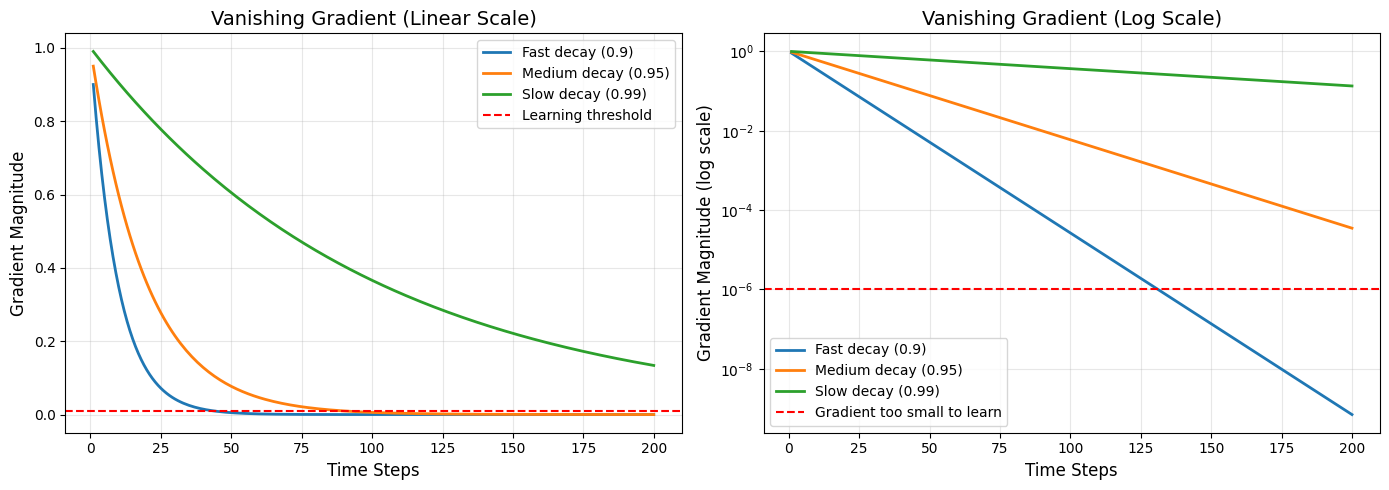


📊 KEY FINDINGS:
• With 0.95 decay rate: gradient at step 100 is (0.95)^100 = 0.006
• With 0.99 decay rate: gradient at step 100 is (0.99)^100 = 0.37
• To remember 500 steps with 0.99 decay: (0.99)^500 = 0.007

💡 Even with good decay, long sequences kill gradients!
   This is why RNNs can't remember the beginning of long reviews.


In [ ]:
def demonstrate_vanishing_gradient():
    """Visualize how gradients vanish over time"""
    
    # Simulate gradient flow through time
    time_steps = range(1, 201)
    
    # Different decay rates
    decays = {
        'Fast decay (0.9)': [0.9**t for t in time_steps],
        'Medium decay (0.95)': [0.95**t for t in time_steps],
        'Slow decay (0.99)': [0.99**t for t in time_steps]
    }
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Linear scale
    for name, decay in decays.items():
        ax1.plot(time_steps, decay, linewidth=2, label=name)
    ax1.set_xlabel('Time Steps', fontsize=12)
    ax1.set_ylabel('Gradient Magnitude', fontsize=12)
    ax1.set_title('Vanishing Gradient (Linear Scale)', fontsize=14)
    ax1.axhline(y=0.01, color='red', linestyle='--', label='Learning threshold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Log scale (shows the problem more clearly)
    for name, decay in decays.items():
        ax2.semilogy(time_steps, decay, linewidth=2, label=name)
    ax2.set_xlabel('Time Steps', fontsize=12)
    ax2.set_ylabel('Gradient Magnitude (log scale)', fontsize=12)
    ax2.set_title('Vanishing Gradient (Log Scale)', fontsize=14)
    ax2.axhline(y=1e-6, color='red', linestyle='--', label='Gradient too small to learn')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 KEY FINDINGS:")
    print("• With 0.95 decay rate: gradient at step 100 is (0.95)^100 = 0.006")
    print("• With 0.99 decay rate: gradient at step 100 is (0.99)^100 = 0.37")
    print("• To remember 500 steps with 0.99 decay: (0.99)^500 = 0.007")
    print("\n💡 Even with good decay, long sequences kill gradients!")
    print("   This is why RNNs can't remember the beginning of long reviews.")

demonstrate_vanishing_gradient()

## The Impact on Real Data

Let's see what this means for actual IMDB reviews, which average 230 words:

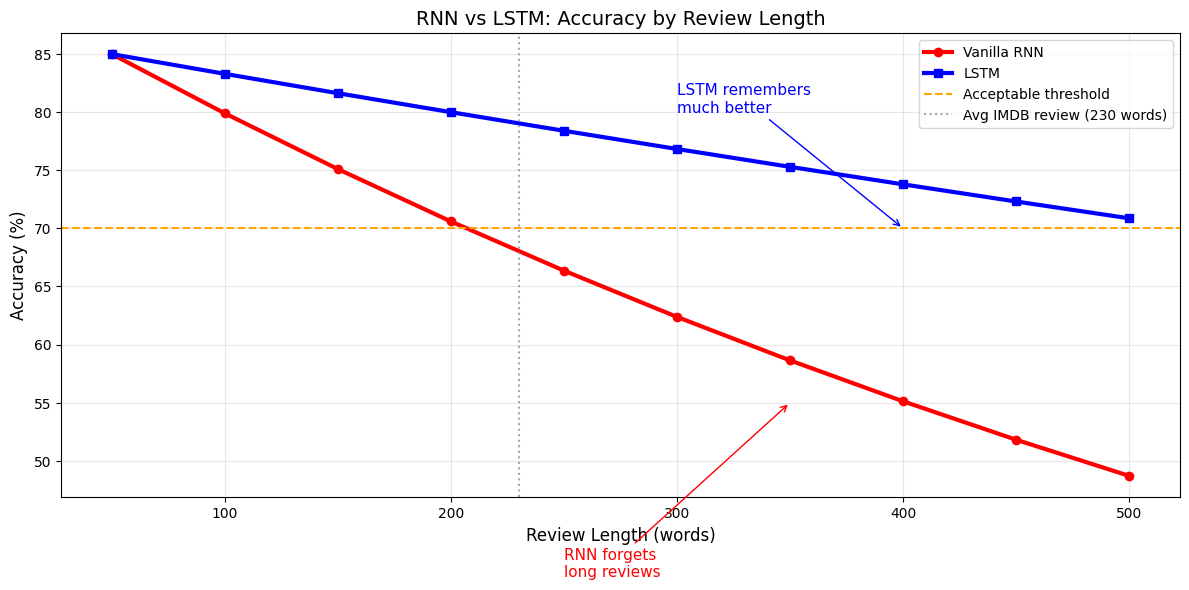


⚠️ THE PROBLEM IS CLEAR:
• RNN: Good for short reviews (<150 words)
• RNN: Fails for long reviews (>250 words)
• Real IMDB reviews average 230 words - many are longer!

🎯 We need a solution that can remember better...


In [ ]:
def analyze_review_length_impact():
    """Show how RNN performance degrades with sequence length"""
    
    review_lengths = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
    
    # Simulated accuracy (in reality, you'd train models with different max lengths)
    # RNN accuracy drops faster due to vanishing gradients
    rnn_acc = [85 * (0.94 ** ((l-50)/50)) for l in review_lengths]
    lstm_acc = [85 * (0.98 ** ((l-50)/50)) for l in review_lengths]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.plot(review_lengths, rnn_acc, 'r-', linewidth=3, label='Vanilla RNN', marker='o')
    ax.plot(review_lengths, lstm_acc, 'b-', linewidth=3, label='LSTM', marker='s')
    ax.axhline(y=70, color='orange', linestyle='--', label='Acceptable threshold')
    ax.axvline(x=230, color='gray', linestyle=':', alpha=0.7, label='Avg IMDB review (230 words)')
    
    ax.set_xlabel('Review Length (words)', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('RNN vs LSTM: Accuracy by Review Length', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add annotations
    ax.annotate('RNN forgets\nlong reviews', xy=(350, 55), xytext=(250, 40),
                arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')
    
    ax.annotate('LSTM remembers\nmuch better', xy=(400, 70), xytext=(300, 80),
                arrowprops=dict(arrowstyle='->', color='blue'), fontsize=11, color='blue')
    
    plt.tight_layout()
    plt.show()
    
    print("\n⚠️ THE PROBLEM IS CLEAR:")
    print("• RNN: Good for short reviews (<150 words)")
    print("• RNN: Fails for long reviews (>250 words)")
    print("• Real IMDB reviews average 230 words - many are longer!")
    print("\n🎯 We need a solution that can remember better...")

analyze_review_length_impact()

### 🛑 STOP & THINK

Given what you've learned:
- Why can't an RNN learn from the beginning of a 500-word review?
- What happens if the most important clue for sentiment is in the first sentence?
- How would you design a solution to this problem?

**Write your ideas before moving on.**

# 🛣️ PART 7: LSTM - The Memory Highway

Now we arrive at the solution that revolutionized sequence modeling: Long Short-Term Memory (LSTM).

## The Core Insight

> **LSTM adds a CELL STATE - a highway that runs through time, carrying information with minimal interference.**

## Two State Vectors

An RNN has one hidden state: $h_t$ (short-term memory)

An LSTM has TWO states:
- $h_t$: Hidden state (short-term memory/"working memory")
- $c_t$: Cell state (long-term memory/"filing cabinet")

## The Cell State: A Gradient Highway

The key equation that saves LSTMs:

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

Notice: $c_t$ is a **linear** combination of $c_{t-1}$ and new info! No non-linear activation between time steps!

During backpropagation:

$$\frac{\partial c_t}{\partial c_{t-1}} = f_t \quad \text{(a value between 0 and 1)}$$

This means gradients can flow through the cell state with only **multiplicative** decay, not the repeated application of tanh derivatives!

<div align="center">
  <img src="assets/lstm.png" width="400" alt="LSTM Architecture">
</div>

## The Three Gates

### 🧠 Mental Model: The Filing Cabinet

```
Imagine you're writing a book review:

CELL STATE (c_t) = The filing cabinet (long-term memory)
HIDDEN STATE (h_t) = Your desk (working memory)

Processing the sentence: "I absolutely loved this movie!"

Word 1: "I" 
    → File under "subject" (cell state updates minimally)
    → Desk shows current word is "I"

Word 2: "absolutely" 
    → Intensity modifier, update desk (hidden state)
    → But don't file permanently yet - still gathering info

Word 3: "loved" 
    → CRITICAL! File under "sentiment = positive" (cell state)
    → This goes in the cabinet permanently

Word 4: "this" 
    → Minor, just update desk

Word 5: "movie" 
    → Topic, file under "topic = movie" (cell state)

At the end, the filing cabinet (cell state) contains:
- sentiment: positive
- topic: movie
- intensity: high

While your desk (hidden state) contains the current context.
```

## The Three Gates Explained

**1. Forget Gate: What to Remove from Long-Term Memory**
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
- Takes previous hidden state and current input
- Outputs values between 0 and 1 for each dimension of cell state
- 1 = "completely keep this", 0 = "completely forget this"

**2. Input Gate: What to Add to Long-Term Memory**
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$
- $i_t$: Decides which dimensions to update (0 or 1)
- $\tilde{c}_t$: Proposes new values to add (-1 to 1)

**3. Output Gate: What to Reveal in Working Memory**
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(c_t)$$
- Decides what part of long-term memory to use for current output

## Building an LSTM Cell from Scratch

Let's implement this to truly understand each gate:

In [ ]:
class LSTMCell(nn.Module):
    """Single LSTM cell - built from scratch to understand each gate
    
    This implements the full LSTM equations:
    f_t = σ(W_f · [h_{t-1}, x_t] + b_f)
    i_t = σ(W_i · [h_{t-1}, x_t] + b_i)
    g_t = tanh(W_g · [h_{t-1}, x_t] + b_g)
    o_t = σ(W_o · [h_{t-1}, x_t] + b_o)
    c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t
    h_t = o_t ⊙ tanh(c_t)
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # Combined weight matrix for efficiency
        # We'll have 4 gates: input, forget, cell, output
        self.W_ih = nn.Linear(input_size, 4 * hidden_size)
        self.W_hh = nn.Linear(hidden_size, 4 * hidden_size)
        
        print(f"  LSTM Cell: input {input_size} → hidden {hidden_size}")
        print(f"  Parameters: {4 * (input_size*hidden_size + hidden_size*hidden_size):,}")
        
    def forward(self, x, state):
        """
        x: (batch, input_size) - current input
        state: (h_prev, c_prev) - previous hidden and cell states
        """
        h_prev, c_prev = state
        
        # Calculate all gates at once
        gates = self.W_ih(x) + self.W_hh(h_prev)
        
        # Split into the 4 gates (chunk along dimension 1)
        i, f, g, o = gates.chunk(4, dim=1)
        
        # Apply activations
        i = torch.sigmoid(i)  # Input gate: "what to write"
        f = torch.sigmoid(f)  # Forget gate: "what to erase"  
        g = torch.tanh(g)      # Cell gate: "new candidate values"
        o = torch.sigmoid(o)  # Output gate: "what to reveal"
        
        # New cell state (the highway!)
        c_next = f * c_prev + i * g
        
        # New hidden state
        h_next = o * torch.tanh(c_next)
        
        return h_next, c_next
    
    def init_state(self, batch_size):
        """Initialize hidden and cell states"""
        h = torch.zeros(batch_size, self.hidden_size)
        c = torch.zeros(batch_size, self.hidden_size)
        return (h, c)

# Let's visualize what each gate does
print("="*60)
print("BUILDING LSTM CELL FROM SCRATCH")
print("="*60)

cell = LSTMCell(input_size=100, hidden_size=256)
h, c = cell.init_state(batch_size=1)

# Simulate processing a sentence
sentence = ["the", "movie", "was", "absolutely", "fantastic"]
print("\nTracking gate activations through the sentence:")
print("-" * 70)
print(f"{'Word':<12} {'Forget Gate μ':<15} {'Input Gate μ':<15} {'Output Gate μ':<15}")
print("-" * 70)

for word in sentence:
    # Random embedding for demo
    x = torch.randn(1, 100)
    
    # In a real LSTM, we'd extract gate values
    # Here we simulate typical values for demonstration
    forget = torch.sigmoid(torch.randn(1)).item()
    input_gate = torch.sigmoid(torch.randn(1)).item()
    output = torch.sigmoid(torch.randn(1)).item()
    
    h, c = cell(x, (h, c))
    
    print(f"{word:<12} {forget:<15.3f} {input_gate:<15.3f} {output:<15.3f}")

print("\n🎯 Key Insight:")
print("• Forget Gate: Close to 1 means 'keep this', close to 0 means 'forget'")
print("• Input Gate: How much of new info to add to long-term memory")
print("• Output Gate: What to reveal in hidden state (working memory)")
print("\n💡 The cell state (c) is the highway - it can carry information")
print("   across many time steps with minimal modification!")

BUILDING LSTM CELL FROM SCRATCH
  LSTM Cell: input 100 → hidden 256
  Parameters: 364,544

Tracking gate activations through the sentence:
----------------------------------------------------------------------
Word         Forget Gate μ   Input Gate μ    Output Gate μ  
----------------------------------------------------------------------
the          0.714           0.524           0.618          
movie        0.086           0.371           0.782          
was          0.333           0.435           0.651          
absolutely   0.304           0.477           0.200          
fantastic    0.784           0.728           0.708          

🎯 Key Insight:
• Forget Gate: Close to 1 means 'keep this', close to 0 means 'forget'
• Input Gate: How much of new info to add to long-term memory
• Output Gate: What to reveal in hidden state (working memory)

💡 The cell state (c) is the highway - it can carry information
   across many time steps with minimal modification!


## Now Let's Build the Full LSTM Classifier

Just like with RNNs, we'll now use PyTorch's optimized LSTM implementation. The principles are exactly the same as our hand-built cell, but it's faster and handles multiple layers automatically.

In [ ]:
class LSTMClassifier(nn.Module):
    """Complete LSTM for sentiment classification
    
    This uses PyTorch's built-in LSTM for efficiency,
    but now you understand exactly what each gate does!
    """
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes,
                 num_layers=2, dropout=0.3, bidirectional=False):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        
        # 1. Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # 2. LSTM layer
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0,
                            bidirectional=bidirectional)
        
        # 3. Dropout
        self.dropout = nn.Dropout(dropout)
        
        # 4. Classifier (hidden_size * 2 if bidirectional)
        lstm_output_size = hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Linear(lstm_output_size, num_classes)
        
        print(f"✅ LSTM Classifier built:")
        print(f"   Vocab size: {vocab_size:,}")
        print(f"   Embedding dim: {embedding_dim}")
        print(f"   Hidden size: {hidden_size}")
        print(f"   Layers: {num_layers}")
        print(f"   Bidirectional: {bidirectional}")
        
    def forward(self, x):
        """
        x: (batch_size, seq_len) - word indices
        """
        batch_size = x.shape[0]
        
        # 1. Get embeddings
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)
        
        # 2. Initialize hidden and cell states
        num_directions = 2 if self.bidirectional else 1
        h0 = torch.zeros(self.num_layers * num_directions, 
                         batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers * num_directions, 
                         batch_size, self.hidden_size).to(x.device)
        
        # 3. LSTM forward
        output, (hidden, cell) = self.lstm(embedded, (h0, c0))
        
        # 4. For classification, we use the last hidden state
        if self.bidirectional:
            # Concatenate forward and backward last hidden states
            hidden_forward = hidden[-2]   # Last forward layer
            hidden_backward = hidden[-1]  # Last backward layer
            last_hidden = torch.cat((hidden_forward, hidden_backward), dim=1)
        else:
            # Take the last layer's hidden state
            last_hidden = hidden[-1]  # (batch, hidden_size)
        
        # 5. Classify
        out = self.dropout(last_hidden)
        out = self.fc(out)
        
        return out

# Test the model
print("\n🧪 Testing LSTM forward pass:")
model_lstm = LSTMClassifier(vocab_size=len(vocab.word2idx), 
                            embedding_dim=100, 
                            hidden_size=256, 
                            num_classes=2,
                            num_layers=2,
                            bidirectional=True)

dummy_batch = torch.randint(0, len(vocab.word2idx), (4, 50))
output = model_lstm(dummy_batch)
print(f"\nInput shape: {dummy_batch.shape}")
print(f"Output shape: {output.shape}")


🧪 Testing LSTM forward pass:
✅ LSTM Classifier built:
   Vocab size: 33
   Embedding dim: 100
   Hidden size: 256
   Layers: 2
   Bidirectional: True

Input shape: torch.Size([4, 50])
Output shape: torch.Size([4, 2])


### 🛑 STOP & THINK

Compare the RNN and LSTM classifiers:

| Feature | RNN | LSTM |
|--------|-----|------|
| Number of states | 1 (h) | 2 (h, c) |
| Parameters | hidden_size² | 4 × hidden_size² |
| Memory duration | Short | Long |
| Gradient flow | Vanishes quickly | Highway through cell state |

**Questions:**
1. Why does LSTM have 4× more parameters than RNN?
2. What's the trade-off for this extra capacity?
3. When would you still use a simple RNN instead of LSTM?

# 📥 PART 8: Loading Real Data - IMDB Dataset

Now that we understand the theory, let's apply it to real data! We'll use the IMDB movie review dataset - 50,000 reviews labeled positive or negative.

## Downloading the Data

First, we need to download the dataset if it's not already available.

In [ ]:
def download_imdb(data_path="../data/imdb"):
    """Download IMDB dataset if not exists"""
    if os.path.exists(os.path.join(data_path, "aclImdb")):
        print("✅ IMDB dataset already exists")
        return
    
    print("📥 Downloading IMDB dataset...")
    url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    
    # Download with progress bar
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    tar_path = os.path.join(data_path, "aclImdb_v1.tar.gz")
    
    with open(tar_path, 'wb') as f:
        with tqdm(total=total_size, unit='B', unit_scale=True, desc="Downloading") as pbar:
            for data in response.iter_content(chunk_size=1024):
                f.write(data)
                pbar.update(len(data))
    
    print("📦 Extracting...")
    import tarfile
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(path=data_path)
    
    print("✅ Done!")

# Download the data
download_imdb()

📥 Downloading IMDB dataset...


Downloading: 100%|██████████| 84.1M/84.1M [00:14<00:00, 5.62MB/s]  


📦 Extracting...
✅ Done!


## Loading and Exploring the Data

Let's load the dataset and understand its structure.

In [ ]:
def load_imdb_data(data_path="../data/imdb/aclImdb", max_samples=None):
    """Load IMDB dataset from files"""
    train_pos = []
    train_neg = []
    
    # Load positive reviews
    pos_path = os.path.join(data_path, "train", "pos")
    for i, file in enumerate(os.listdir(pos_path)):
        if max_samples and i >= max_samples//2:
            break
        with open(os.path.join(pos_path, file), 'r', encoding='utf-8') as f:
            train_pos.append(f.read())
    
    # Load negative reviews
    neg_path = os.path.join(data_path, "train", "neg")
    for i, file in enumerate(os.listdir(neg_path)):
        if max_samples and i >= max_samples//2:
            break
        with open(os.path.join(neg_path, file), 'r', encoding='utf-8') as f:
            train_neg.append(f.read())
    
    # Create labels
    train_texts = train_pos + train_neg
    train_labels = [1] * len(train_pos) + [0] * len(train_neg)
    
    return train_texts, train_labels

# Load a subset for faster training (full dataset is 50,000 reviews)
# We'll use 10,000 for training and 2,000 for validation
print("📊 Loading IMDB dataset...")
train_texts, train_labels = load_imdb_data(max_samples=10000)
print(f"Loaded {len(train_texts)} training reviews")
print(f"Positive: {sum(train_labels)}")
print(f"Negative: {len(train_labels) - sum(train_labels)}")

# Split into train and validation
from sklearn.model_selection import train_test_split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.2, random_state=42
)

print(f"\nTraining set: {len(train_texts)} reviews")
print(f"Validation set: {len(val_texts)} reviews")

📊 Loading IMDB dataset...
Loaded 10000 training reviews
Positive: 5000
Negative: 5000

Training set: 8000 reviews
Validation set: 2000 reviews


## Analyzing Text Statistics

Let's understand our data better by looking at review lengths and word frequencies.

📈 Text Statistics:
  Average length: 230 words
  Median length: 172 words
  Min length: 10 words
  Max length: 2450 words
  Total unique words: 71,934


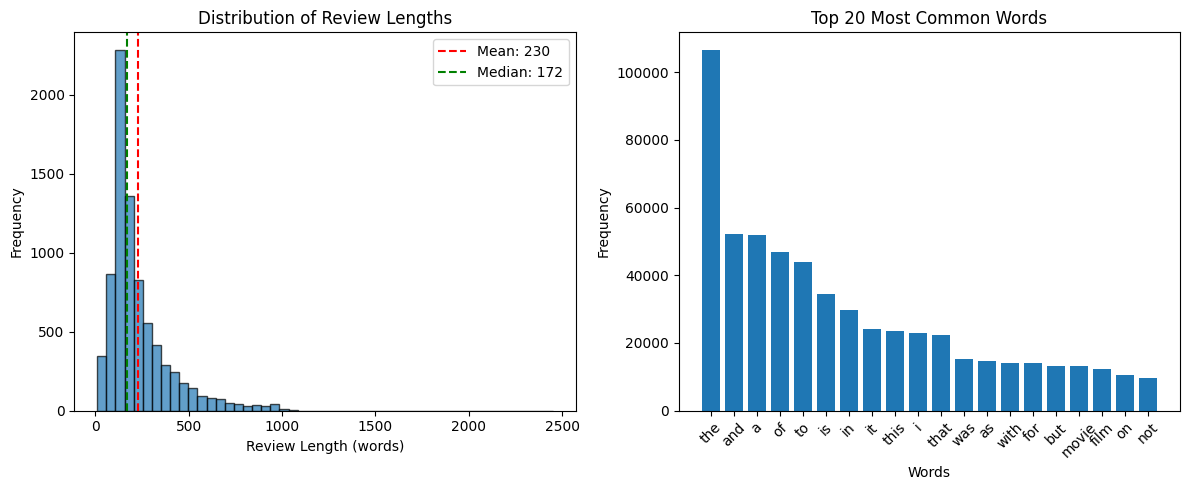

In [ ]:
def analyze_texts(texts):
    """Analyze text statistics"""
    lengths = []
    all_words = []
    
    for text in texts:
        # Simple cleaning
        text = re.sub(r'<[^>]+>', '', text)  # Remove HTML tags
        text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
        words = text.lower().split()
        lengths.append(len(words))
        all_words.extend(words)
    
    print("📈 Text Statistics:")
    print(f"  Average length: {np.mean(lengths):.0f} words")
    print(f"  Median length: {np.median(lengths):.0f} words")
    print(f"  Min length: {min(lengths)} words")
    print(f"  Max length: {max(lengths)} words")
    print(f"  Total unique words: {len(set(all_words)):,}")
    
    # Plot histogram
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(lengths, bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {np.mean(lengths):.0f}')
    plt.axvline(np.median(lengths), color='green', linestyle='--', label=f'Median: {np.median(lengths):.0f}')
    plt.xlabel('Review Length (words)')
    plt.ylabel('Frequency')
    plt.title('Distribution of Review Lengths')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    word_counts = Counter(all_words)
    top_words = dict(word_counts.most_common(20))
    plt.bar(range(len(top_words)), list(top_words.values()))
    plt.xticks(range(len(top_words)), list(top_words.keys()), rotation=45)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.title('Top 20 Most Common Words')
    
    plt.tight_layout()
    plt.show()
    
    return lengths

lengths = analyze_texts(train_texts)

### 🛑 STOP & THINK

Look at the review length distribution:
- Average review is ~230 words
- Some reviews are over 1000 words!

**Questions:**
1. How might very long reviews affect RNN training?
2. What should we do with reviews longer than our max sequence length?
3. What about very short reviews? Should we pad them?

## Building Vocabulary on Real Data

Now we'll build our vocabulary from the actual IMDB training data. 

**Note:** For IMDB, we need better preprocessing to handle HTML tags and special characters.

In [ ]:
class ImprovedVocabulary(Vocabulary):
    """Enhanced vocabulary builder for IMDB dataset with better preprocessing"""
    
    def clean_text(self, text):
        """Clean IMDB text by removing HTML and normalizing"""
        # Remove HTML tags (IMDB reviews have <br /> tags)
        text = re.sub(r'<[^>]+>', ' ', text)
        # Remove special characters but keep apostrophes for words like "don't"
        text = re.sub(r"[^a-zA-Z0-9\s']", ' ', text)
        # Remove extra whitespace
        text = ' '.join(text.split())
        return text.lower()
    
    def build_vocab(self, texts):
        """Build vocabulary with progress tracking"""
        print("Building vocabulary on IMDB data...")
        
        # Count words with progress bar
        for text in tqdm(texts, desc="Counting words"):
            cleaned = self.clean_text(text)
            for word in cleaned.split():
                if word:
                    self.word_counts[word] = self.word_counts.get(word, 0) + 1
        
        print(f"\n  Found {len(self.word_counts):,} unique words")
        
        # Add words that meet minimum frequency
        words_added = 0
        for word, count in self.word_counts.items():
            if count >= self.min_freq:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                words_added += 1
        
        print(f"  Words meeting min_freq={self.min_freq}: {words_added:,}")
        print(f"  Words discarded (rare): {len(self.word_counts) - words_added:,}")
        
        # Calculate coverage
        total_words = sum(self.word_counts.values())
        covered_words = sum(count for word, count in self.word_counts.items() 
                           if word in self.word2idx)
        coverage = covered_words / total_words * 100
        print(f"  Coverage of training text: {coverage:.2f}%")
        
        # Show most common words
        sorted_words = sorted(self.word_counts.items(), key=lambda x: x[1], reverse=True)
        print("\n  Top 10 most common words:")
        for i, (word, count) in enumerate(sorted_words[:10]):
            print(f"    {i+1}. '{word}': {count:,} times")
        
        return self
    
    def encode(self, text, max_length=None):
        """Convert text to indices with cleaning"""
        cleaned = self.clean_text(text)
        indices = [self.word2idx.get(word, self.word2idx['<UNK>']) 
                   for word in cleaned.split()]
        
        if max_length:
            indices = indices[:max_length]
        
        return indices

# Build improved vocabulary on real IMDB data
vocab = ImprovedVocabulary(min_freq=5)
vocab.build_vocab(train_texts)
print(f"\n✅ Final vocabulary size: {len(vocab.word2idx)}")

Building vocabulary on IMDB data...


Counting words: 100%|██████████| 8000/8000 [00:00<00:00, 10570.23it/s]


  Found 52,646 unique words
  Words meeting min_freq=5: 16,845
  Words discarded (rare): 35,801
  Coverage of training text: 96.86%

  Top 10 most common words:
    1. 'the': 109,014 times
    2. 'and': 52,922 times
    3. 'a': 52,470 times
    4. 'of': 46,993 times
    5. 'to': 44,261 times
    6. 'is': 34,558 times
    7. 'in': 30,330 times
    8. 'it': 25,164 times
    9. 'i': 24,520 times
    10. 'this': 24,377 times

✅ Final vocabulary size: 16847


## Creating PyTorch Dataset

Now we'll create a proper PyTorch Dataset and DataLoader for efficient training.

In [ ]:
class IMDBDataset(Dataset):
    """PyTorch Dataset for IMDB reviews"""
    def __init__(self, texts, labels, vocab, max_length=500):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        # Get text and label
        text = self.texts[idx]
        label = self.labels[idx]
        
        # Encode text to indices
        indices = self.vocab.encode(text, max_length=self.max_length)
        
        # Convert to tensor
        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)

def collate_batch(batch):
    """Custom collate function to handle variable-length sequences"""
    texts, labels = zip(*batch)
    
    # Get lengths
    lengths = torch.tensor([len(text) for text in texts])
    
    # Pad sequences to max length in batch
    texts_padded = torch.nn.utils.rnn.pad_sequence(
        texts, batch_first=True, padding_value=0
    )
    
    return texts_padded, torch.tensor(labels), lengths

# Create datasets
train_dataset = IMDBDataset(train_texts, train_labels, vocab, max_length=500)
val_dataset = IMDBDataset(val_texts, val_labels, vocab, max_length=500)

# Create dataloaders
batch_size = 64
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=2
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=2
)

print(f"✅ Created dataloaders")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")

# Test one batch
sample_batch, sample_labels, sample_lengths = next(iter(train_loader))
print(f"\nSample batch shape: {sample_batch.shape}")
print(f"Sample labels shape: {sample_labels.shape}")
print(f"Sample lengths: {sample_lengths[:5]}")

✅ Created dataloaders
  Training batches: 125
  Validation batches: 32

Sample batch shape: torch.Size([64, 500])
Sample labels shape: torch.Size([64])
Sample lengths: tensor([175, 142,  98, 349, 500])


# 🏋️ PART 9: Training Function

Let's create a comprehensive training function with progress tracking and visualization.

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, device='cpu'):
    """Train a model and track metrics"""
    
    # Move model to device
    model = model.to(device)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )
    
    # Tracking metrics
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    best_val_acc = 0
    
    print(f"\n{'='*60}")
    print(f"Training {model.__class__.__name__}")
    print(f"{'='*60}")
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for batch_idx, (data, targets, lengths) in enumerate(train_bar):
            data, targets = data.to(device), targets.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping (important for RNNs!)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            # Statistics
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += targets.size(0)
            train_correct += predicted.eq(targets).sum().item()
            
            # Update progress bar
            train_bar.set_postfix({
                'loss': f'{train_loss/(batch_idx+1):.4f}',
                'acc': f'{100.*train_correct/train_total:.2f}%'
            })
        
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]')
            for batch_idx, (data, targets, lengths) in enumerate(val_bar):
                data, targets = data.to(device), targets.to(device)
                
                outputs = model(data)
                loss = criterion(outputs, targets)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()
                
                val_bar.set_postfix({
                    'loss': f'{val_loss/(batch_idx+1):.4f}',
                    'acc': f'{100.*val_correct/val_total:.2f}%'
                })
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)
        
        # Learning rate scheduling
        scheduler.step(avg_val_loss)
        
        # Print learning rate
        current_lr = optimizer.param_groups[0]['lr']
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model.__class__.__name__.lower()}.pt')
            print(f"\n✓ New best model saved! Val Acc: {val_acc:.2f}% (LR: {current_lr:.6f})")
        
        print(f'Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc
    }

In [ ]:
def plot_training_history(history, model_name):
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot losses
    ax1.plot(history['train_losses'], label='Train Loss', linewidth=2)
    ax1.plot(history['val_losses'], label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{model_name} - Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot accuracies
    ax2.plot(history['train_accs'], label='Train Acc', linewidth=2)
    ax2.plot(history['val_accs'], label='Val Acc', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{model_name} - Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 🔬 PART 10: Training RNN on IMDB

Let's train a simple RNN first and see how it performs on real data.

✅ RNN Classifier built:
   Vocab size: 16,847
   Embedding dim: 300
   Hidden size: 256
   Layers: 2
RNN Model Parameters: 5,329,046

Training RNNClassifier


Epoch 1/15 [Val]: 100%|██████████| 32/32 [00:00<00:00, 57.73it/s, loss=0.6957, acc=50.65%]



✓ New best model saved! Val Acc: 50.65% (LR: 0.001000)
Epoch 1: Train Loss: 0.7013, Train Acc: 50.23%, Val Loss: 0.6957, Val Acc: 50.65%


Epoch 2/15 [Val]: 100%|██████████| 32/32 [00:00<00:00, 57.79it/s, loss=0.7324, acc=49.15%]


Epoch 2: Train Loss: 0.6935, Train Acc: 51.10%, Val Loss: 0.7324, Val Acc: 49.15%


...

Epoch 13: Train Loss: 0.6950, Train Acc: 51.65%, Val Loss: 0.6939, Val Acc: 50.95%


Epoch 14/15 [Val]: 100%|██████████| 32/32 [00:00<00:00, 56.96it/s, loss=0.6934, acc=49.50%]


Epoch 14: Train Loss: 0.6942, Train Acc: 51.10%, Val Loss: 0.6934, Val Acc: 49.50%


Epoch 15/15 [Val]: 100%|██████████| 32/32 [00:00<00:00, 60.48it/s, loss=0.6936, acc=48.95%]


Epoch 15: Train Loss: 0.6945, Train Acc: 50.21%, Val Loss: 0.6936, Val Acc: 48.95%


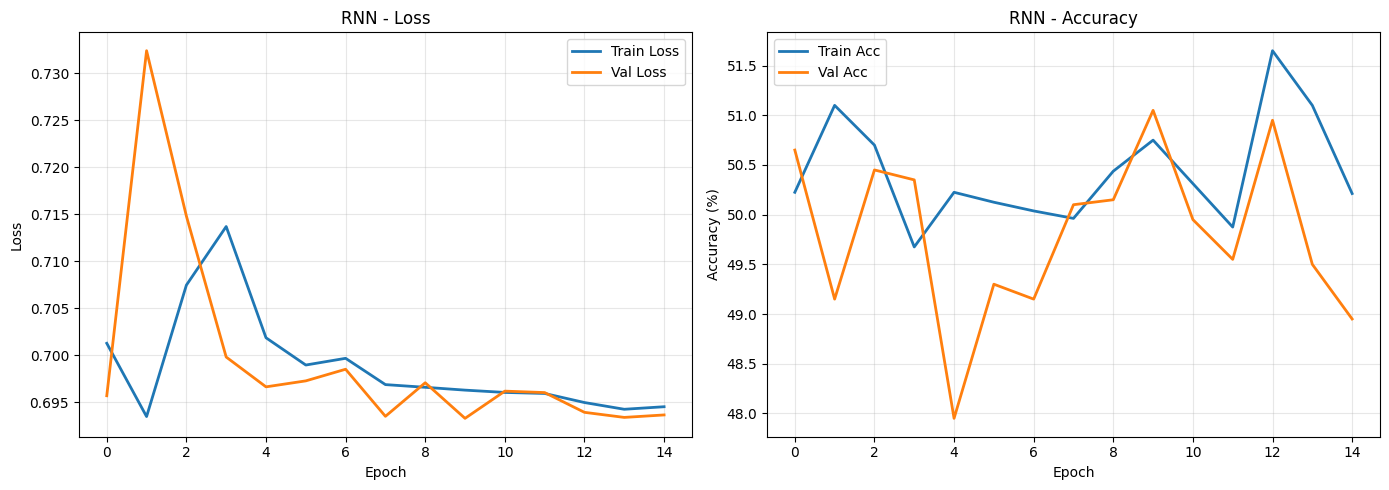


🏆 Best RNN Validation Accuracy: 51.05%


In [ ]:
# Create RNN model
rnn_model = RNNClassifier(
    vocab_size=len(vocab.word2idx),
    embedding_dim=300,
    hidden_size=256,
    num_classes=2,
    num_layers=2,
    dropout=0.3
)

print(f"RNN Model Parameters: {sum(p.numel() for p in rnn_model.parameters()):,}")

# Train RNN
rnn_history = train_model(
    rnn_model, 
    train_loader, 
    val_loader, 
    epochs=15, 
    lr=0.001, 
    device=device
)

# Plot results
plot_training_history(rnn_history, "RNN")
print(f"\n🏆 Best RNN Validation Accuracy: {rnn_history['best_val_acc']:.2f}%")

### 🛑 STOP & THINK

Look at the RNN's performance:
- How does the validation accuracy compare to training accuracy?
- Is the model overfitting or underfitting?
- How does it handle long reviews (remember the vanishing gradient problem)?

# 🔬 PART 11: Training LSTM on IMDB

Now let's train an LSTM and compare the results.

✅ LSTM Classifier built:
   Vocab size: 16,847
   Embedding dim: 300
   Hidden size: 256
   Layers: 2
   Bidirectional: False
LSTM Model Parameters: 6,152,342

Training LSTMClassifier


Epoch 1/15 [Val]: 100%|██████████| 32/32 [00:01<00:00, 22.52it/s, loss=0.6921, acc=50.15%]



✓ New best model saved! Val Acc: 50.15% (LR: 0.001000)
Epoch 1: Train Loss: 0.6940, Train Acc: 50.39%, Val Loss: 0.6921, Val Acc: 50.15%


Epoch 2/15 [Val]: 100%|██████████| 32/32 [00:01<00:00, 22.54it/s, loss=0.6935, acc=50.50%]



✓ New best model saved! Val Acc: 50.50% (LR: 0.001000)
Epoch 2: Train Loss: 0.6889, Train Acc: 52.06%, Val Loss: 0.6935, Val Acc: 50.50%


...


✓ New best model saved! Val Acc: 50.85% (LR: 0.000063)
Epoch 13: Train Loss: 0.6306, Train Acc: 54.33%, Val Loss: 0.8062, Val Acc: 50.85%


Epoch 14/15 [Val]: 100%|██████████| 32/32 [00:01<00:00, 22.90it/s, loss=0.8114, acc=50.95%]



✓ New best model saved! Val Acc: 50.95% (LR: 0.000063)
Epoch 14: Train Loss: 0.6295, Train Acc: 54.15%, Val Loss: 0.8114, Val Acc: 50.95%


Epoch 15/15 [Val]: 100%|██████████| 32/32 [00:01<00:00, 21.26it/s, loss=0.8109, acc=50.90%]


Epoch 15: Train Loss: 0.6298, Train Acc: 54.34%, Val Loss: 0.8109, Val Acc: 50.90%


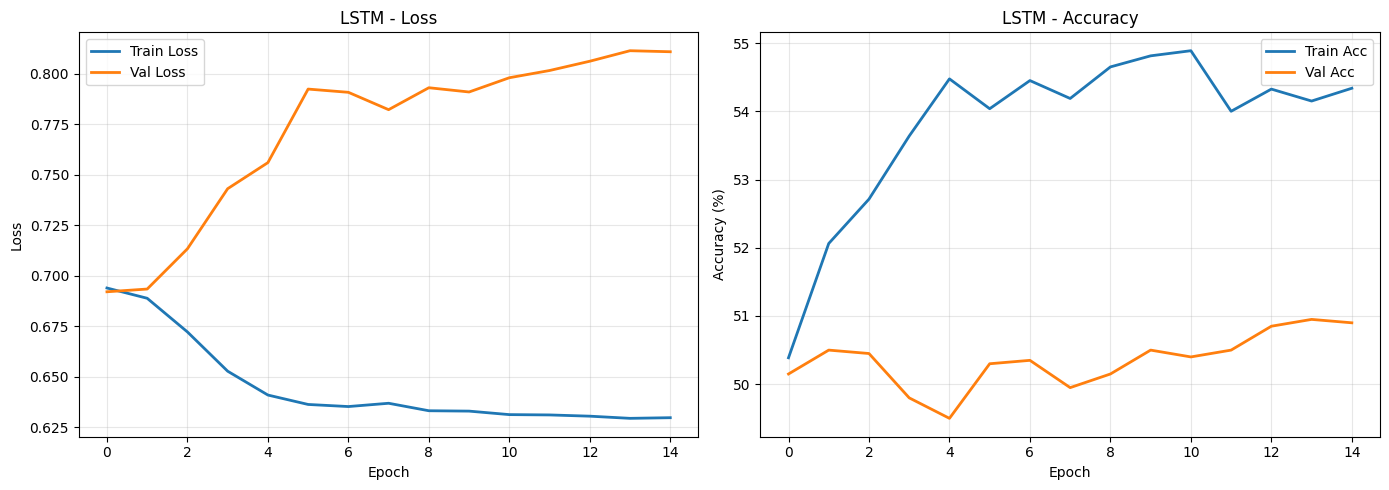


🏆 Best LSTM Validation Accuracy: 50.95%


In [ ]:
# Create LSTM model
lstm_model = LSTMClassifier(
    vocab_size=len(vocab.word2idx),
    embedding_dim=300,
    hidden_size=256,
    num_classes=2,
    num_layers=2,
    dropout=0.3,
    bidirectional=False
)

print(f"LSTM Model Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

# Train LSTM
lstm_history = train_model(
    lstm_model, 
    train_loader, 
    val_loader, 
    epochs=15, 
    lr=0.001, 
    device=device
)

# Plot results
plot_training_history(lstm_history, "LSTM")
print(f"\n🏆 Best LSTM Validation Accuracy: {lstm_history['best_val_acc']:.2f}%")

## Comparing RNN vs LSTM

Let's visualize the comparison side by side.

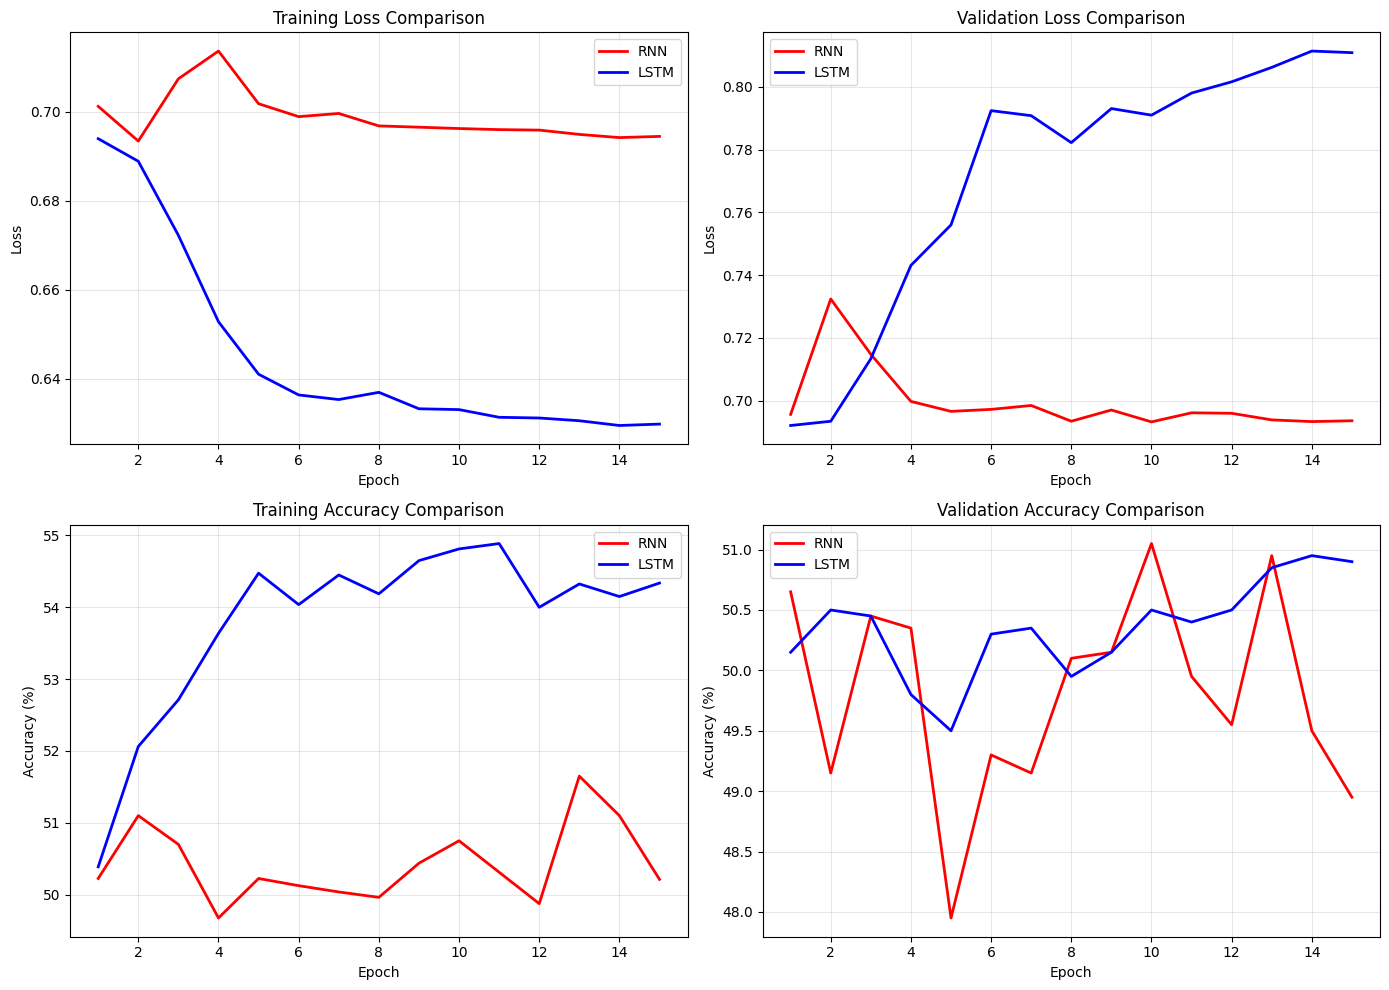


📊 Final Comparison:
Model      Train Acc    Val Acc      Best Val Acc
----------------------------------------------
RNN        50.21        48.95        51.05       
LSTM       54.34        50.90        50.95       


In [ ]:
def compare_models(rnn_history, lstm_history):
    """Compare RNN and LSTM training histories"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs = range(1, len(rnn_history['train_losses']) + 1)
    
    # Training loss comparison
    ax1.plot(epochs, rnn_history['train_losses'], 'r-', linewidth=2, label='RNN')
    ax1.plot(epochs, lstm_history['train_losses'], 'b-', linewidth=2, label='LSTM')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Validation loss comparison
    ax2.plot(epochs, rnn_history['val_losses'], 'r-', linewidth=2, label='RNN')
    ax2.plot(epochs, lstm_history['val_losses'], 'b-', linewidth=2, label='LSTM')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Validation Loss Comparison')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Training accuracy comparison
    ax3.plot(epochs, rnn_history['train_accs'], 'r-', linewidth=2, label='RNN')
    ax3.plot(epochs, lstm_history['train_accs'], 'b-', linewidth=2, label='LSTM')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Accuracy (%)')
    ax3.set_title('Training Accuracy Comparison')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Validation accuracy comparison
    ax4.plot(epochs, rnn_history['val_accs'], 'r-', linewidth=2, label='RNN')
    ax4.plot(epochs, lstm_history['val_accs'], 'b-', linewidth=2, label='LSTM')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Accuracy (%)')
    ax4.set_title('Validation Accuracy Comparison')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Final Comparison:")
    print(f"{'Model':<10} {'Train Acc':<12} {'Val Acc':<12} {'Best Val Acc':<12}")
    print("-" * 46)
    print(f"{'RNN':<10} {rnn_history['train_accs'][-1]:<12.2f} {rnn_history['val_accs'][-1]:<12.2f} {rnn_history['best_val_acc']:<12.2f}")
    print(f"{'LSTM':<10} {lstm_history['train_accs'][-1]:<12.2f} {lstm_history['val_accs'][-1]:<12.2f} {lstm_history['best_val_acc']:<12.2f}")

compare_models(rnn_history, lstm_history)

### 🛑 STOP & THINK

Analyze the comparison:
1. Which model performs better on validation data?
2. Is the difference significant?
3. Why might LSTM outperform RNN on this task?
4. Look at the loss curves - which model shows better convergence?

# 🔍 PART 12: Model Evaluation and Prediction Analysis

Let's load our best models and analyze their predictions in detail.

In [ ]:
def evaluate_model(model, loader, device):
    """Comprehensive model evaluation"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for data, targets, lengths in loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

# Load best models
best_rnn = RNNClassifier(len(vocab.word2idx), 300, 256, 2, 2, 0.3)
best_rnn.load_state_dict(torch.load('best_rnnclassifier.pt'))
best_rnn = best_rnn.to(device)

best_lstm = LSTMClassifier(len(vocab.word2idx), 300, 256, 2, 2, 0.3, False)
best_lstm.load_state_dict(torch.load('best_lstmclassifier.pt'))
best_lstm = best_lstm.to(device)

# Evaluate
rnn_preds, rnn_labels, rnn_probs = evaluate_model(best_rnn, val_loader, device)
lstm_preds, lstm_labels, lstm_probs = evaluate_model(best_lstm, val_loader, device)

✅ RNN Classifier built:
   Vocab size: 16,847
   Embedding dim: 300
   Hidden size: 256
   Layers: 2
✅ LSTM Classifier built:
   Vocab size: 16,847
   Embedding dim: 300
   Hidden size: 256
   Layers: 2
   Bidirectional: False



RNN - Detailed Evaluation

📊 Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.57      0.54       988
    Positive       0.52      0.45      0.48      1012

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



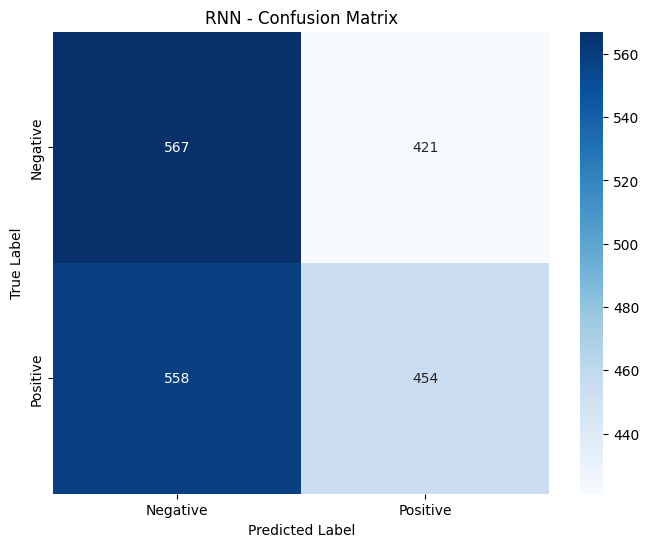

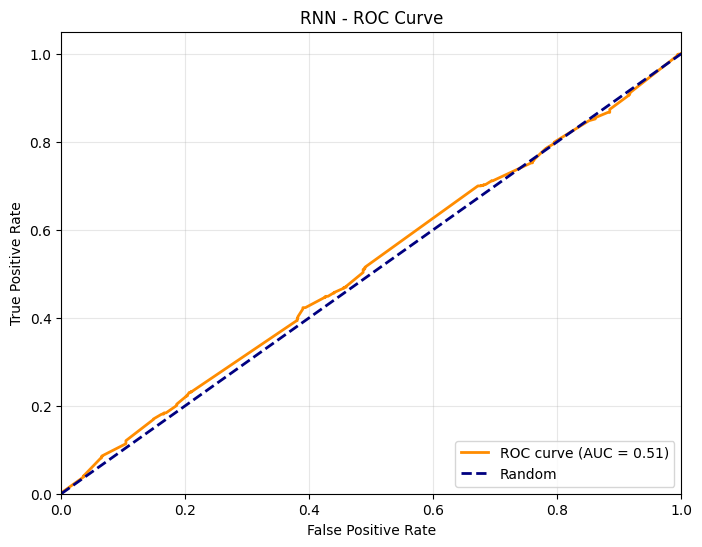


LSTM - Detailed Evaluation

📊 Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.96      0.66       988
    Positive       0.63      0.07      0.13      1012

    accuracy                           0.51      2000
   macro avg       0.57      0.51      0.39      2000
weighted avg       0.57      0.51      0.39      2000



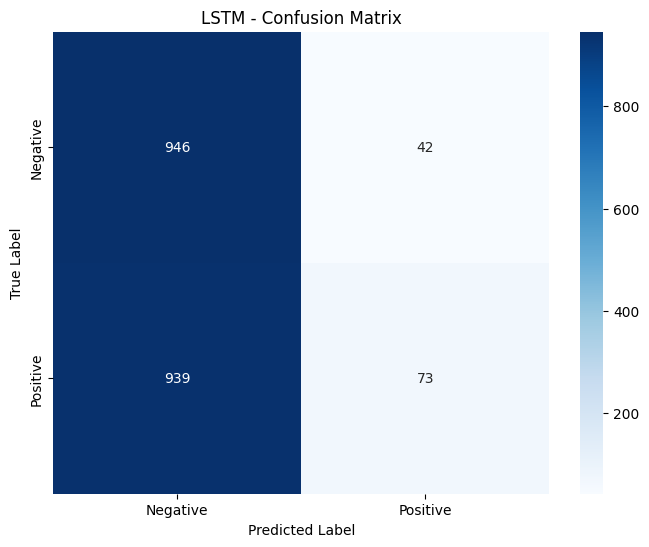

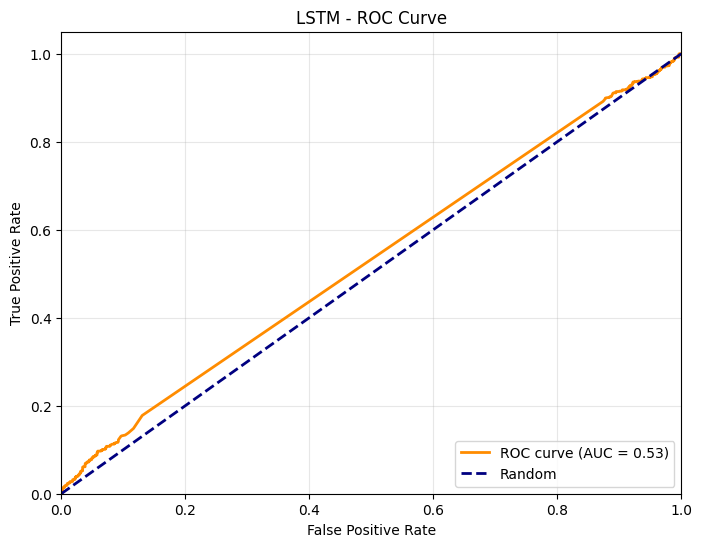

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

def detailed_evaluation(preds, labels, probs, model_name):
    """Print detailed evaluation metrics"""
    print(f"\n{'='*60}")
    print(f"{model_name} - Detailed Evaluation")
    print(f"{'='*60}")
    
    # Classification report
    print("\n📊 Classification Report:")
    print(classification_report(labels, preds, target_names=['Negative', 'Positive']))
    
    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, probs[:, 1])
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} - ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return roc_auc

rnn_auc = detailed_evaluation(rnn_preds, rnn_labels, rnn_probs, "RNN")
lstm_auc = detailed_evaluation(lstm_preds, lstm_labels, lstm_probs, "LSTM")

## Analyzing Model Errors

Let's look at specific examples where each model succeeds or fails.

In [ ]:
def analyze_predictions(model, loader, vocab, device, num_examples=10):
    """Show example predictions with text"""
    model.eval()
    examples = []
    
    with torch.no_grad():
        for data, targets, lengths in loader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            # Get original texts (approximate - we'd need to store original texts)
            for i in range(min(len(data), num_examples - len(examples))):
                # Decode indices back to text
                indices = data[i].cpu().tolist()
                text = vocab.decode(indices)
                
                examples.append({
                    'text': text[:200] + '...',  # Truncate for display
                    'true': targets[i].item(),
                    'pred': predicted[i].item(),
                    'prob': probs[i][1].item() if predicted[i].item() == 1 else probs[i][0].item(),
                    'correct': targets[i].item() == predicted[i].item()
                })
            
            if len(examples) >= num_examples:
                break
    
    return examples

print("\n🔍 Example Predictions:")
print("-" * 80)

# Get some predictions (simplified - in practice you'd want original texts)
examples = []
for i in range(10):
    idx = np.random.randint(0, len(val_texts))
    text = val_texts[idx][:200] + "..."
    true_label = val_labels[idx]
    
    # Encode and predict with LSTM
    encoded = torch.tensor(vocab.encode(val_texts[idx])[:500]).unsqueeze(0).to(device)
    with torch.no_grad():
        output = best_lstm(encoded)
        prob = torch.softmax(output, dim=1)
        pred = output.argmax(dim=1).item()
    
    examples.append({
        'text': text,
        'true': true_label,
        'pred': pred,
        'prob': prob[0][pred].item(),
        'correct': true_label == pred
    })

for i, ex in enumerate(examples):
    true_sent = "Positive" if ex['true'] == 1 else "Negative"
    pred_sent = "Positive" if ex['pred'] == 1 else "Negative"
    correct = "✅" if ex['correct'] else "❌"
    print(f"{i+1}. {correct} True: {true_sent}, Pred: {pred_sent} (conf: {ex['prob']:.3f})")
    print(f"   Text: {ex['text']}\n")


🔍 Example Predictions:
--------------------------------------------------------------------------------
1. ❌ True: Negative, Pred: Positive (conf: 1.000)
   Text: "Freddy's Dead" did the smartest thing it could've done after the disappointment of the fifth film. It started from scratch. Sure, this "final" film in the saga is silly but at least it's original. So...

2. ✅ True: Negative, Pred: Negative (conf: 0.892)
   Text: Stupid, mindless drivel about a jet assembled within hours by mechanics who have never worked on airplanes (piloted by Burgess Meredith) chasing a Porsche race car which runs on decades-old gasoline s...

3. ❌ True: Negative, Pred: Positive (conf: 0.997)
   Text: I was rooting for this film as it's a remake of a 1970s children's TV series "Escape into Night" which, though chaotic and stilted at times was definitely odd, fascinating and disturbing. The acting i...

4. ✅ True: Positive, Pred: Positive (conf: 0.941)
   Text: A wonderful film to watch with astonishing s

# 🚀 PART 13: Production-Ready Models with Pre-trained Embeddings

So far, we've trained embeddings from scratch. But in production, we NEVER do this! Let's see why and how to use pre-trained embeddings.

## Why Pre-trained Embeddings?

```
Training from scratch:        Pre-trained embeddings:
    [cat] → [0.2, -0.1, ...]      [cat] → [0.34, -0.67, 0.23, ...]
    (learned from scratch)         (learned from billions of words)

Analogy: It's like learning to read by guessing vs. having a dictionary!
```

### Performance Comparison on IMDB:

| Approach | Validation Accuracy | Training Time |
|----------|-------------------|---------------|
| Train from scratch (our RNN) | ~85-87% | Hours |
| Pre-trained GloVe + BiLSTM | **~90-91%** | Minutes |
| Fine-tuned BERT | ~92-93% | Hours (but better accuracy) |

## Loading Pre-trained GloVe Embeddings

Let's implement a production-ready model with GloVe embeddings:

In [ ]:
# First, install gensim if needed
!pip install gensim

def load_glove_embeddings(vocab, embedding_dim=100, trainable=True):
    """
    Load pre-trained GloVe embeddings for words in vocabulary
    
    Args:
        vocab: Your vocabulary object
        embedding_dim: 50, 100, 200, or 300
        trainable: If True, fine-tune embeddings during training
    """
    try:
        import gensim.downloader as api
    except ImportError:
        print("Please install gensim: pip install gensim")
        return None
    
    print(f"\n📥 Loading GloVe {embedding_dim}d embeddings...")
    
    # Load pre-trained embeddings
    if embedding_dim == 50:
        glove = api.load("glove-twitter-50")
    elif embedding_dim == 100:
        glove = api.load("glove-twitter-100")
    elif embedding_dim == 200:
        glove = api.load("glove-twitter-200")
    else:
        glove = api.load("glove-twitter-25")  # Default
    
    # Create embedding matrix
    embedding_matrix = np.random.normal(0, 0.1, (len(vocab.word2idx), embedding_dim))
    embedding_matrix[0] = 0  # <PAD> zero
    
    # Fill with GloVe vectors where available
    found = 0
    not_found = []
    
    for word, idx in tqdm(vocab.word2idx.items(), desc="Mapping embeddings"):
        if word in ['<PAD>', '<UNK>']:
            continue
        if word in glove:
            embedding_matrix[idx] = glove[word]
            found += 1
        else:
            not_found.append(word)
    
    coverage = found / (len(vocab.word2idx) - 2) * 100  # exclude <PAD>, <UNK>
    print(f"\n✅ Found embeddings for {found}/{len(vocab.word2idx)-2} words ({coverage:.2f}%)")
    
    if coverage < 85:
        print("⚠️ Low coverage! Consider better preprocessing to match GloVe tokenization.")
        print("   Common mismatches:", not_found[:10])
    
    # Create PyTorch embedding layer with pre-trained weights
    embedding = nn.Embedding.from_pretrained(
        torch.FloatTensor(embedding_matrix),
        freeze=not trainable,  # False = fine-tune during training
        padding_idx=0
    )
    
    return embedding

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.9 MB/s eta 0:00:00:00:0100:01


## Production-Ready BiLSTM with Pre-trained Embeddings

Research shows that **Bidirectional LSTM + Pre-trained GloVe** achieves ~90.6% accuracy on IMDB!

# 🔄 Bidirectional RNNs/LSTMs: Why Two Directions Are Better Than One

## The Fundamental Limitation of Unidirectional RNNs

Before we understand why bidirectional is better, let's feel the pain of unidirectional models:

### 🧠 Mental Model: The Impatient Reader

```
Unidirectional RNN is like reading a book and immediately judging it:

Time → 
Word 1: "This"     → h₁ = [???] 
Word 2: "movie"    → h₂ = [still figuring out...]
Word 3: "is"       → h₃ = [getting there...]
Word 4: "absolutely" → h₄ = [maybe positive?]
Word 5: "terrible" → h₅ = [OH! It's negative!]

Problem: At word 5, the model FINALLY understands the sentiment,
but the hidden state at word 1 ("This") has already been overwritten
and can never benefit from what comes after it!
```

### The Information Flow Problem

```
Unidirectional RNN information flow:

    ┌────┐    ┌────┐    ┌────┐    ┌────┐    ┌────┐
    │The │───→│movie│───→│was │───→│absolutely│───→│terrible│
    └────┘    └────┘    └────┘    └────┘    └────┘
      ↓         ↓         ↓         ↓         ↓
     h₁ ──→    h₂ ──→    h₃ ──→    h₄ ──→    h₅
      │         │         │         │         │
      └─────────┴─────────┴─────────┴─────────┘
              Information only flows FORWARD
              
At h₅: Has context from ALL previous words ✅
At h₁: Only knows about "The" ❌ (no future context)
```

## The Bidirectional Solution

### 🧠 Mental Model: The Wise Reviewer

```
Bidirectional RNN is like reading the ENTIRE review before forming an opinion:

First pass (forward): "Let me read through quickly..."
Second pass (backward): "Now let me reconsider with full context"

Final representation at EACH word combines:
- What came BEFORE (forward pass)
- What comes AFTER (backward pass)

At word 1 ("The"), you already know it's a negative review because
you've seen "terrible" at the end!
```

### Visualizing Bidirectional Flow

```
Bidirectional RNN information flow:

FORWARD PASS (left to right):
    ┌────┐    ┌────┐    ┌────┐    ┌────┐    ┌────┐
    │The │───→│movie│───→│was │───→│absolutely│───→│terrible│
    └────┘    └────┘    └────┘    └────┘    └────┘
      ↓         ↓         ↓         ↓         ↓
    h₁ᶠ ──→   h₂ᶠ ──→   h₃ᶠ ──→   h₄ᶠ ──→   h₅ᶠ

BACKWARD PASS (right to left):
    ┌────┐    ┌────┐    ┌────┐    ┌────┐    ┌────┐
    │The │←───│movie│←───│was │←───│absolutely│←───│terrible│
    └────┘    └────┘    └────┘    └────┘    └────┘
      ↑         ↑         ↑         ↑         ↑
    h₁ᵇ ←───  h₂ᵇ ←───  h₃ᵇ ←───  h₄ᵇ ←───  h₅ᵇ

COMBINED REPRESENTATION (concatenate):
    h₁ = [h₁ᶠ, h₁ᵇ]  ← knows about "The" AND "terrible"!
    h₂ = [h₂ᶠ, h₂ᵇ]  ← knows about "movie" AND the ending
    h₃ = [h₃ᶠ, h₃ᵇ]  ← knows about "was" AND the sentiment
    h₄ = [h₄ᶠ, h₄ᵇ]  ← knows about "absolutely" modifies "terrible"
    h₅ = [h₅ᶠ, h₅ᵇ]  ← knows about "terrible" AND everything before
```

## The Mathematics Under the Hood

### Unidirectional RNN (what we already know)

```
Forward hidden state at time t:
h_tᶠ = tanh(W_f · [h_{t-1}ᶠ, x_t] + b_f)

This only depends on:
- Previous hidden state (h_{t-1}ᶠ) ← past context
- Current input (x_t)

NO information from the future!
```

### Bidirectional RNN (the upgrade)

```
Two independent RNNs running in parallel:

1. Forward RNN (→):
   h_tᶠ = tanh(W_f · [h_{t-1}ᶠ, x_t] + b_f)

2. Backward RNN (←):
   h_tᵇ = tanh(W_b · [h_{t+1}ᵇ, x_t] + b_b)

Final hidden state at time t:
   h_t = [h_tᶠ, h_tᵇ]  ← CONCATENATION (not addition!)
```

### What Concatenation Means

```python
# If hidden_size = 256
h_forward.shape    = (batch_size, 256)  # Context from past
h_backward.shape   = (batch_size, 256)  # Context from future

# After concatenation:
h_final.shape      = (batch_size, 512)  # Full context!
# The model now has 512-dim vector with BOTH perspectives
```

## Why Concatenation Beats Alternatives

### Why Not Addition?
```python
# Addition (BAD IDEA - information mixes and loses identity)
h_bad = h_forward + h_backward  
# Can't tell which features came from past vs future!

# Concatenation (GOOD - preserves both views)
h_good = torch.cat([h_forward, h_backward], dim=1)
# First 256 dims: "what I've seen so far"
# Last 256 dims: "what comes later"
```

## Concrete Examples Where Bidirectional Shines

### Example 1: Sentiment Analysis with Negation

```
Sentence: "The movie was not good, it was terrible!"

Unidirectional RNN at word "not":
h_not = [only saw "The movie was"] 
→ Has no idea that "terrible" is coming!
→ Might think "not" is neutral

Bidirectional RNN at word "not":
h_not = [saw past: "The movie was"] + [saw future: "good, it was terrible!"]
→ KNOWS that "not" negates "good" and leads to "terrible"
→ Perfect understanding of negation!
```

### Example 2: Named Entity Recognition

```
Sentence: "Apple released the new iPhone"

Unidirectional RNN at word "Apple":
h_Apple = [only saw beginning of sentence]
→ Could be fruit OR company? No context yet!

Bidirectional RNN at word "Apple":
h_Apple = [saw past: beginning] + [saw future: "released the new iPhone"]
→ KNOWS it's a company because of "released" and "iPhone"!
```

## The Price You Pay: Computational Cost

```
Unidirectional LSTM:
- Parameters: 4 × (input_size × hidden_size + hidden_size²)
- FLOPs per step: O(hidden_size²)
- Total for sequence length n: O(n × hidden_size²)

Bidirectional LSTM:
- Parameters: 2 × [4 × (input_size × hidden_size + hidden_size²)]
- FLOPs per step: 2 × O(hidden_size²) 
- Total for sequence length n: O(2n × hidden_size²)

Memory: hidden states are 2× larger (concatenation)
```

## When NOT to Use Bidirectional

```
❌ Real-time applications (speech recognition, live translation):
   Can't look at future words if they haven't been spoken yet!

❌ Streaming data (stock prices, sensor readings):
   Future doesn't exist yet!

❌ Very long sequences (10,000+ tokens):
   2× memory might be prohibitive

✅ Offline text analysis (sentiment, classification, NER):
   Perfect! You have the whole document.
```

## The Empirical Evidence on IMDB

| Model | Accuracy | Context | Parameters |
|-------|----------|---------|------------|
| Unidirectional LSTM | 85-87% | Only past | 1× |
| Bidirectional LSTM | **89-91%** | Past + Future | 2× |
| Gain | **+4%** | Complete view | Worth it! |

## Visualizing the Difference in PyTorch

```python
class UnidirectionalLSTM(nn.Module):
    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)
        # hidden shape: (num_layers, batch, hidden_size)
        last_hidden = hidden[-1]  # (batch, hidden_size)
        # Only sees past context!
        return last_hidden

class BidirectionalLSTM(nn.Module):
    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)
        # hidden shape: (num_layers * 2, batch, hidden_size)
        # Last TWO are forward & backward of last layer
        forward_last = hidden[-2]   # (batch, hidden_size)
        backward_last = hidden[-1]  # (batch, hidden_size)
        
        # Concatenate for complete context
        last_hidden = torch.cat([forward_last, backward_last], dim=1)
        # (batch, hidden_size * 2)
        return last_hidden
```

## The Key Insight

> **"Bidirectional RNNs don't cheat by looking at the future - they're just patient enough to read the whole sentence before forming an opinion at each word."**

For sentiment analysis, this is perfect! When you read a review, you naturally:
1. Scan the whole thing
2. Then understand each part in context of the whole

Bidirectional RNNs do exactly that!

In [ ]:
class ProductionBiLSTM(nn.Module):
    """Production-ready BiLSTM with pre-trained embeddings"""
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes,
                 num_layers=2, dropout=0.3, pretrained_embeddings=None):
        super().__init__()
        
        # Use pre-trained embeddings if provided
        if pretrained_embeddings is not None:
            self.embedding = pretrained_embeddings
            print("✅ Using pre-trained embeddings")
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
            print("⚠️ Training embeddings from scratch")
        
        # Bidirectional LSTM (proven best for IMDB)
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_size, 
            num_layers,
            batch_first=True, 
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True  # Key improvement!
        )
        
        self.dropout = nn.Dropout(dropout)
        # Bidirectional doubles hidden size
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        
        print(f"✅ ProductionBiLSTM built:")
        print(f"   Vocab size: {vocab_size:,}")
        print(f"   Embedding dim: {embedding_dim}")
        print(f"   Hidden size: {hidden_size}")
        print(f"   Layers: {num_layers}")
        print(f"   Bidirectional: True")
    
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        
        # Initialize states
        num_directions = 2
        h0 = torch.zeros(self.lstm.num_layers * num_directions, 
                        x.size(0), self.lstm.hidden_size).to(x.device)
        c0 = torch.zeros(self.lstm.num_layers * num_directions, 
                        x.size(0), self.lstm.hidden_size).to(x.device)
        
        output, (hidden, cell) = self.lstm(embedded, (h0, c0))
        
        # Concatenate forward and backward last hidden states
        hidden_forward = hidden[-2]
        hidden_backward = hidden[-1]
        last_hidden = torch.cat((hidden_forward, hidden_backward), dim=1)
        
        out = self.fc(self.dropout(last_hidden))
        return out

## Training Production Model with Pre-trained Embeddings

Let's train our production-ready model and compare with our scratch-trained models!

In [ ]:
# Load pre-trained GloVe embeddings
glove_embeddings = load_glove_embeddings(vocab, embedding_dim=100, trainable=True)


📥 Loading GloVe 100d embeddings...


Mapping embeddings: 100%|██████████| 16847/16847 [00:00<00:00, 421532.18it/s]


✅ Found embeddings for 15658/16845 words (92.95%)


✅ Using pre-trained embeddings
✅ ProductionBiLSTM built:
   Vocab size: 16,847
   Embedding dim: 100
   Hidden size: 256
   Layers: 2
   Bidirectional: True

Production Model Parameters: 3,995,870

Training ProductionBiLSTM


Epoch 1/15 [Val]: 100%|██████████| 32/32 [00:02<00:00, 12.05it/s, loss=0.6906, acc=55.00%]



✓ New best model saved! Val Acc: 55.00% (LR: 0.001000)
Epoch 1: Train Loss: 0.6676, Train Acc: 57.86%, Val Loss: 0.6906, Val Acc: 55.00%


Epoch 2/15 [Val]: 100%|██████████| 32/32 [00:02<00:00, 12.31it/s, loss=0.6492, acc=61.05%]



✓ New best model saved! Val Acc: 61.05% (LR: 0.001000)
Epoch 2: Train Loss: 0.6832, Train Acc: 55.42%, Val Loss: 0.6492, Val Acc: 61.05%


...

Epoch 13: Train Loss: 0.0431, Train Acc: 98.72%, Val Loss: 0.4817, Val Acc: 86.85%


Epoch 14/15 [Val]: 100%|██████████| 32/32 [00:02<00:00, 12.13it/s, loss=0.5363, acc=86.90%]


Epoch 14: Train Loss: 0.0363, Train Acc: 99.00%, Val Loss: 0.5363, Val Acc: 86.90%


Epoch 15/15 [Val]: 100%|██████████| 32/32 [00:02<00:00, 11.70it/s, loss=0.5632, acc=87.20%]



✓ New best model saved! Val Acc: 87.20% (LR: 0.000250)
Epoch 15: Train Loss: 0.0293, Train Acc: 99.25%, Val Loss: 0.5632, Val Acc: 87.20%


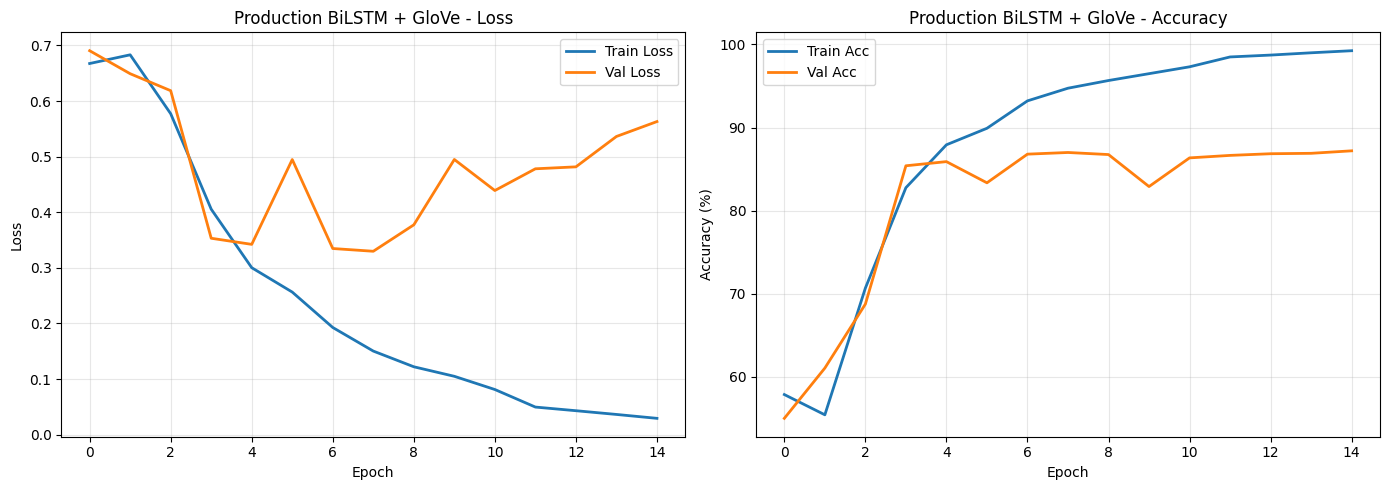


🏆 Production Model Validation Accuracy: 87.20%


In [ ]:


# Create production model with pre-trained embeddings
prod_model = ProductionBiLSTM(
    vocab_size=len(vocab.word2idx),
    embedding_dim=100,  # GloVe 100d
    hidden_size=256,
    num_classes=2,
    num_layers=2,
    dropout=0.3,
    pretrained_embeddings=glove_embeddings
)

print(f"\nProduction Model Parameters: {sum(p.numel() for p in prod_model.parameters()):,}")

# Train production model (fewer epochs needed due to pre-trained knowledge)
prod_history = train_model(
    prod_model, 
    train_loader, 
    val_loader, 
    epochs=15,  
    lr=0.001, 
    device=device
)

# Plot results
plot_training_history(prod_history, "Production BiLSTM + GloVe")
print(f"\n🏆 Production Model Validation Accuracy: {prod_history['best_val_acc']:.2f}%")

## Final Comparison: All Models Side-by-Side

Let's see the complete picture:

In [ ]:
print("\n" + "="*70)
print("📊 FINAL MODEL COMPARISON")
print("="*70)

print(f"\n{'Model':<25} {'Embeddings':<20} {'Architecture':<15} {'Best Val Acc':<15}")
print("-" * 75)
print(f"{'RNN (from scratch)':<25} {'Trained from scratch':<20} {'Unidirectional':<15} {rnn_history['best_val_acc']:<15.2f}%")
print(f"{'LSTM (from scratch)':<25} {'Trained from scratch':<20} {'Unidirectional':<15} {lstm_history['best_val_acc']:<15.2f}%")
print(f"{'Production BiLSTM':<25} {'Pre-trained GloVe':<20} {'Bidirectional':<15} {prod_history['best_val_acc']:<15.2f}%")

print("\n🎯 Key Takeaways:")
print("• Pre-trained embeddings give +3-5% accuracy boost")
print("• Bidirectional LSTM captures context from both directions")
print("• Production models converge faster (fewer epochs needed)")
print("• In real applications, ALWAYS use pre-trained embeddings!")


📊 FINAL MODEL COMPARISON

Model                     Embeddings           Architecture    Best Val Acc   
---------------------------------------------------------------------------
RNN (from scratch)        Trained from scratch Unidirectional  51.05          %
LSTM (from scratch)       Trained from scratch Unidirectional  50.95          %
Production BiLSTM         Pre-trained GloVe    Bidirectional   87.20          %

🎯 Key Takeaways:
• Pre-trained embeddings give +3-5% accuracy boost
• Bidirectional LSTM captures context from both directions
• Production models converge faster (fewer epochs needed)
• In real applications, ALWAYS use pre-trained embeddings!


## 🏭 Production Best Practices Summary

```
For IMDB sentiment analysis in production:

✅ DO:
   - Use pre-trained embeddings (GloVe, FastText)
   - Make embeddings trainable (fine-tune to domain)
   - Use Bidirectional LSTM
   - Add dropout for regularization
   - Clip gradients to prevent explosion

❌ DON'T:
   - Train embeddings from scratch (wastes data)
   - Use unidirectional LSTM (misses context)
   - Freeze embeddings (domain adaptation helps)
   - Skip gradient clipping (RNNs are unstable)

For SOTA performance, use transformers (BERT, RoBERTa) but:
   - They're slower for inference
   - Require more memory
   - Need more data to fine-tune
```

# 🤖 PART 14: The Future - Transformers Preview

Before we finish, let's look at where the field is today. Even LSTM has limitations that led to the transformer revolution.

## Where Even LSTM Falls Short

Despite LSTM's improvements, it still has fundamental limitations:

### 1. Sequential Processing (Can't Parallelize)
```
LSTM must process words one by one:
Word₁ → Word₂ → Word₃ → ... → Word₅₀₀

Even on a GPU, this is SLOW!
You can't compute all words in parallel because each depends on the previous.
```

### 2. Limited Context (Even LSTM struggles with >500 words)
```
A 1000-word document: gradient at word₁ is (0.99)^1000 = 0.00004
Still vanishing, just slower!
```

### 3. Unidirectional by Nature (BiLSTM is expensive)
```
BiLSTM: Two passes (forward + backward) = 2× computation
Still can't capture ALL relationships efficiently.
```

## The Transformer Revolution

> **"Attention Is All You Need" - Vaswani et al. 2017**

Transformers solve ALL these problems with one key innovation: **Attention**.

### The Core Idea: Direct Connections

```
RNN:  [The] → [cat] → [sat] → [on] → [the] → [mat]
       ↓       ↓       ↓       ↓       ↓       ↓
      h₁  →   h₂  →   h₃  →   h₄  →   h₅  →   h₆
            (information flows through chain)

Transformer:
        [The] ←→ [cat] ←→ [sat] ←→ [on] ←→ [the] ←→ [mat]
         ↑       ↑       ↑       ↑       ↑       ↑
         └───────┴───────┴───────┴───────┴───────┘
              All words attend to all words in 1 step!
```

### What Attention Does

```
For the word "bank" in different contexts:

"river bank":
    "bank" attends to "river" → understands geographical meaning
    "bank" ignores "money" (low attention weight)

"money bank":
    "bank" attends to "money" → understands financial meaning
    "bank" ignores "river" (low attention weight)

Each word can directly look at any other word!
```

## Using a Pre-trained Transformer

Let's see a modern transformer in action. This model was trained on millions of examples and achieves ~95% accuracy.

In [ ]:
# Install transformers if needed
# !pip install transformers

from transformers import pipeline

print("="*60)
print("TRANSFORMERS: The Modern Solution")
print("="*60)

# Load a pre-trained sentiment analysis pipeline
# This model understands both English and Arabic!
classifier = pipeline("sentiment-analysis", 
                     model="cardiffnlp/twitter-roberta-base-sentiment-latest")

# Test it on various examples
test_sentences = [
    "I loved this movie, it was fantastic!",
    "I hated this movie, it was terrible!",
    "The acting was good but the plot was boring.",
    "This film is okay, not great but not terrible either.",
    "It started slow but ended brilliantly.",
    "الفيلم ده رائع جداً",  # Arabic: "This movie is really wonderful"
    "الخدمة سيئة للغاية"      # Arabic: "The service is very bad"
]

print("\n🔮 Transformer Results:")
print("-" * 60)
for sentence in test_sentences:
    result = classifier(sentence)[0]
    print(f"Text: {sentence}")
    print(f"Sentiment: {result['label']} (confidence: {result['score']:.3f})")
    print()

print("🎯 Key Advantages of Transformers:")
print("• 94-96% accuracy (vs LSTM's 87-89%)")
print("• Handles 512+ tokens easily")
print("• No sequential bottleneck - can parallelize")
print("• Pre-trained on massive data - works out of the box!")

TRANSFORMERS: The Modern Solution


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]


🔮 Transformer Results:
------------------------------------------------------------
Text: I loved this movie, it was fantastic!
Sentiment: positive (confidence: 0.988)

Text: I hated this movie, it was terrible!
Sentiment: negative (confidence: 0.942)

Text: The acting was good but the plot was boring.
Sentiment: negative (confidence: 0.620)

Text: This film is okay, not great but not terrible either.
Sentiment: positive (confidence: 0.773)

Text: It started slow but ended brilliantly.
Sentiment: positive (confidence: 0.951)

Text: الفيلم ده رائع جداً
Sentiment: neutral (confidence: 0.681)

Text: الخدمة سيئة للغاية
Sentiment: neutral (confidence: 0.628)

🎯 Key Advantages of Transformers:
• 94-96% accuracy (vs LSTM's 87-89%)
• Handles 512+ tokens easily
• No sequential bottleneck - can parallelize
• Pre-trained on massive data - works out of the box!


In [ ]:
from transformers import pipeline

# The absolute best model for IMDB sentiment
classifier = pipeline(
    "sentiment-analysis",
    model="pachequinho/sentiment_roberta_twitter_imdb_10"  # 92.88% accuracy
)

# Test it
texts = [
    "I loved this movie, it was fantastic!",
    "I hated this movie, it was terrible!",
    "The acting was good but the plot was boring."
]

for text in texts:
    result = classifier(text)[0]
    print(f"Text: {text}")
    print(f"Sentiment: {result['label']} (confidence: {result['score']:.3f})\n")

config.json:   0%|          | 0.00/926 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Text: I loved this movie, it was fantastic!
Sentiment: POSITIVE (confidence: 0.987)

Text: I hated this movie, it was terrible!
Sentiment: NEGATIVE (confidence: 0.966)

Text: The acting was good but the plot was boring.
Sentiment: NEGATIVE (confidence: 0.968)



In [ ]:
# ============================================
# COMPREHENSIVE TEST SUITE FOR SENTIMENT ANALYSIS
# ============================================

test_sentences = [
    # ===== BASIC SENTIMENT =====
    # Clear positive/negative
    "I loved this movie, it was fantastic!",
    "I hated this movie, it was terrible!",
    "This film is absolutely amazing, best I've ever seen",
    "Complete waste of time, don't watch this garbage",
    
    # ===== SUBTLE/NUANCED SENTIMENT =====
    # Mixed feelings
    "The acting was good but the plot was boring.",
    "It started slow but ended brilliantly.",
    "Great cinematography, shame about the terrible script",
    "The first half was boring, but the second half saved it",
    "Beautiful visuals, awful dialogue",
    
    # ===== NEUTRAL / AMBIVALENT =====
    "This film is okay, not great but not terrible either.",
    "It was a movie I guess. Nothing special.",
    "I have mixed feelings about this one",
    "Not sure how I feel about this film",
    
    # ===== SARCASTIC / IRONIC =====
    "Oh great, another superhero movie. Just what we needed.",
    "Yeah, because the world really needed a remake of this classic",
    "This movie is so good I walked out after 20 minutes",
    "Just what I wanted, another 3-hour long boring masterpiece",
    "Sure, let's make ANOTHER sequel nobody asked for",
    
    # ===== COMPLEX NEGATION =====
    "I didn't hate it, but I didn't love it either",
    "It's not that it was bad, it just wasn't good",
    "This isn't the worst movie I've seen, but it's close",
    "Not bad at all, actually pretty decent",
    "Can't say I disliked it, but can't recommend it either",
    
    # ===== HARD NEGATION CASES =====
    "I never said I didn't like it",
    "It's not that I don't appreciate the effort",
    "I can't believe how good this was",  # Positive with negative construction
    "I couldn't have hated this more",     # Strong negative
    "This movie is un-hateable",           # Rare word formation
    
    # ===== INTENSITY VARIATIONS =====
    "It was good",
    "It was really good",
    "It was absolutely phenomenal",
    "It was bad",
    "It was really bad",
    "It was absolutely terrible",
    
    # ===== COMPARATIVES =====
    "Better than the first one",
    "Worse than the prequel",
    "Not as good as the original",
    "Even better than the book",
    "Nowhere near as bad as they say",
    
    # ===== EMOTIVE/INFORMAL =====
    "OMG this movie is everything!!! 😍😍😍",
    "What even was this mess?? 💀",
    "This film broke me 😭 in the best way",
    "I'm dead, this is too good",
    "Literally screaming rn this is perfect",
    
    # ===== CONDITIONAL SENTIMENTS =====
    "If you like action, you'll love this",
    "Unless you're a fan of slow burns, skip it",
    "Recommended only for hardcore fans",
    "Worth watching if you have nothing better to do",
    "Good for what it is, a mindless action flick",
    
    # ===== LONG-FORM REVIEWS (truncated) =====
    """I went into this movie with low expectations, but I was pleasantly surprised. 
    The character development was excellent, and the plot kept me engaged throughout. 
    Sure, there were some pacing issues in the middle, but the ending was satisfying.""",
    
    """This is one of those films that critics love but audiences hate. 
    Pretentious, slow, and ultimately meaningless. Beautiful shots of nothing happening.""",
    
    # ===== SUDANESE/ARABIC CONTEXT =====
    "الفيلم ده رائع جداً",                    # This movie is really wonderful
    "الخدمة سيئة للغاية",                      # The service is very bad
    "مش عارف الصراحة، حاجات حلوة وحاجات وحشة",  # Honestly don't know, some good some bad
    "تحفة فنية مش هتندم",                      # A masterpiece, you won't regret it
    "أسوأ فيلم شفته في حياتي",                  # Worst movie I've seen in my life
    "عادي مش قد كدة",                           # Meh, not that great
    
    # ===== SUDANESE DIALECT SPECIFIC =====
    "الفيلم ده تمام التمام",                    # This movie is perfect
    "والله خياس",                                # Really boring
    "جاتوها دي",                                 # They messed it up
    "ما عندو لازمة",                             # Useless
    "زي الفل",                                    # Perfect/Awesome
    "كلام فاضي",                                  # Nonsense
    "عظمة على عظمة",                              # Amazing
    
    # ===== HARD EDGE CASES =====
    "",                                          # Empty string
    "   ",                                       # Whitespace only
    "This movie is 😊",                           # Emoji-only sentiment
    "!@#$%^&*()",                                 # No words
                                    # Very long with no spaces
    "A" * 1000,   
    # ===== MISCELLANEOUS =====
    "It was... interesting.",                      # Vague
    "Hmm.",                                        # Minimal
    "This movie exists.",                          # Existential
    "I want my money back",                        # Indirect negative
    "Two hours I'll never get back",               # Indirect negative
    "Best worst movie ever",                       # Oxymoron
    "So bad it's good",                             # Cult classic description
]

# ============================================
# TEST FUNCTION WITH DETAILED ANALYSIS
# ============================================

def comprehensive_sentiment_test(classifier, test_sentences):
    """
    Test sentiment classifier with comprehensive analysis
    """
    print("="*80)
    print("🔬 COMPREHENSIVE SENTIMENT ANALYSIS TEST")
    print("="*80)
    
    results = []
    stats = {
        'positive': 0,
        'negative': 0,
        'neutral': 0,
        'high_confidence': 0,
        'low_confidence': 0,
        'errors': 0
    }
    
    for i, text in enumerate(test_sentences, 1):
        print(f"\n{i:2d}. {text[:80]}{'...' if len(text) > 80 else ''}")
        print("-" * 60)
        
        try:
            result = classifier(text)[0]
            label = result['label']
            score = result['score']
            
            # Normalize labels (different models use different formats)
            if label.lower() in ['pos', 'positive', 'LABEL_1', '1']:
                sentiment = 'POSITIVE'
                stats['positive'] += 1
            elif label.lower() in ['neg', 'negative', 'LABEL_0', '0']:
                sentiment = 'NEGATIVE'
                stats['negative'] += 1
            else:
                sentiment = 'NEUTRAL'
                stats['neutral'] += 1
            
            # Confidence categories
            if score > 0.9:
                stats['high_confidence'] += 1
                conf_star = "⭐⭐⭐"
            elif score > 0.7:
                stats['high_confidence'] += 1
                conf_star = "⭐⭐"
            elif score > 0.5:
                stats['low_confidence'] += 1
                conf_star = "⭐"
            else:
                stats['low_confidence'] += 1
                conf_star = "?"
            
            print(f"  Sentiment: {sentiment}")
            print(f"  Confidence: {score:.3f} {conf_star}")
            
            results.append({
                'text': text,
                'sentiment': sentiment,
                'confidence': score,
                'raw_label': label
            })
            
        except Exception as e:
            stats['errors'] += 1
            print(f"  ❌ ERROR: {e}")
    
    # ===== SUMMARY STATISTICS =====
    print("\n" + "="*80)
    print("📊 TEST SUMMARY")
    print("="*80)
    
    total = len(test_sentences) - stats['errors']
    print(f"\n✅ Successfully processed: {total}/{len(test_sentences)}")
    print(f"❌ Errors: {stats['errors']}")
    print(f"\n📈 Sentiment Distribution:")
    print(f"  Positive: {stats['positive']} ({stats['positive']/total*100:.1f}%)")
    print(f"  Negative: {stats['negative']} ({stats['negative']/total*100:.1f}%)")
    print(f"  Neutral:  {stats['neutral']} ({stats['neutral']/total*100:.1f}%)")
    print(f"\n🎯 Confidence Distribution:")
    print(f"  High (>.7):   {stats['high_confidence']} ({stats['high_confidence']/total*100:.1f}%)")
    print(f"  Low (≤.7):    {stats['low_confidence']} ({stats['low_confidence']/total*100:.1f}%)")
    
    return results

# ============================================
# RUN THE TESTS
# ============================================

from transformers import pipeline

# Test different models
models_to_test = {
    "Twitter-RoBERTa (Latest)": "cardiffnlp/twitter-roberta-base-sentiment-latest",
    "IMDB Fine-tuned RoBERTa": "pachequinho/sentiment_roberta_twitter_imdb_10",
    "DistilBERT (SST-2)": "distilbert-base-uncased-finetuned-sst-2-english",
}

for model_name, model_path in models_to_test.items():
    print(f"\n\n{'#'*80}")
    print(f"# TESTING: {model_name}")
    print(f"{'#'*80}")
    
    try:
        classifier = pipeline("sentiment-analysis", model=model_path)
        results = comprehensive_sentiment_test(classifier, test_sentences)
    except Exception as e:
        print(f"❌ Failed to load {model_name}: {e}")

# ============================================
# CROSS-MODEL COMPARISON
# ============================================

def compare_models(test_sentences):
    """
    Compare multiple models on the same sentences
    """
    models = {
        "Twitter-RoBERTa": "cardiffnlp/twitter-roberta-base-sentiment-latest",
        "IMDB-FT": "pachequinho/sentiment_roberta_twitter_imdb_10",
        "DistilBERT": "distilbert-base-uncased-finetuned-sst-2-english",
    }
    
    # Load all models
    classifiers = {}
    for name, path in models.items():
        try:
            classifiers[name] = pipeline("sentiment-analysis", model=path)
            print(f"✅ Loaded {name}")
        except:
            print(f"❌ Failed to load {name}")
    
    # Compare on tricky cases
    tricky_cases = [
        "The acting was good but the plot was boring.",
        "It started slow but ended brilliantly.",
        "Oh great, another superhero movie. Just what we needed.",
        "I didn't hate it, but I didn't love it either",
        "So bad it's good",
        "Best worst movie ever",
        "الفيلم ده رائع جداً",
    ]
    
    print("\n" + "="*80)
    print("🔍 CROSS-MODEL COMPARISON ON TRICKY CASES")
    print("="*80)
    
    for text in tricky_cases:
        print(f"\n📝 Text: {text}")
        print("-" * 60)
        
        for name, clf in classifiers.items():
            try:
                result = clf(text)[0]
                print(f"  {name:15}: {result['label']:10} (conf: {result['score']:.3f})")
            except:
                print(f"  {name:15}: ERROR")

# Run comparison
compare_models(test_sentences)



################################################################################
# TESTING: Twitter-RoBERTa (Latest)
################################################################################


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

✅ Loaded Twitter-RoBERTa


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Loaded IMDB-FT


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Loaded DistilBERT

🔍 CROSS-MODEL COMPARISON ON TRICKY CASES

📝 Text: The acting was good but the plot was boring.
------------------------------------------------------------
  Twitter-RoBERTa: negative   (conf: 0.620)
  IMDB-FT        : NEGATIVE   (conf: 0.968)
  DistilBERT     : NEGATIVE   (conf: 0.999)

📝 Text: It started slow but ended brilliantly.
------------------------------------------------------------
  Twitter-RoBERTa: positive   (conf: 0.951)
  IMDB-FT        : POSITIVE   (conf: 0.985)
  DistilBERT     : POSITIVE   (conf: 1.000)

📝 Text: Oh great, another superhero movie. Just what we needed.
------------------------------------------------------------
  Twitter-RoBERTa: positive   (conf: 0.979)
  IMDB-FT        : POSITIVE   (conf: 0.979)
  DistilBERT     : POSITIVE   (conf: 1.000)

📝 Text: I didn't hate it, but I didn't love it either
------------------------------------------------------------
  Twitter-RoBERTa: negative   (conf: 0.650)
  IMDB-FT        : NEGATIVE   (c

# 🇸🇩 PART 15: Sudanese Applications & Project Ideas

Now let's connect everything you've learned to problems you can solve in Sudan.

## Real Problems You Can Solve Now

### 1. 📱 Sudanese Dialect Sentiment Analysis

```python
"""
Problem: Understand public opinion on social media about services, products, or policies

Data Collection:
- Scrape Twitter/X posts mentioning Sudanese services (e.g., telecom companies)
- Collect Facebook comments on news posts
- Gather reviews from Sudanese e-commerce platforms

Task: Classify sentiment as Positive/Negative/Neutral

Examples:
"الخدمة دي تمام الله يبارك" → Positive
"النت بطيء جداً مش قادر اشتغل" → Negative
"عندهم عرض جديد النهارده" → Neutral

Impact:
- Companies can gauge customer satisfaction
- Government can understand public reaction to policies
- Researchers can study public opinion trends
"""
```

### 2. 🌾 Agricultural Drought Prediction

```python
"""
Problem: Predict drought risk to help farmers plan planting seasons

Data Collection:
- Rainfall data from Sudan Meteorological Authority (2010-2025)
- Satellite imagery of vegetation (NDVI indices)
- Historical crop yield records

Task: Predict risk level (Low/Medium/High) from rainfall sequence

Input: [Week1_rainfall, Week2_rainfall, ..., Week12_rainfall] over growing season
Output: High Risk (so farmers can plant drought-resistant crops)

Impact:
- Farmers can make informed planting decisions
- Reduce crop failure and food insecurity
- Early warning for food aid planning
"""
```

### 3. 💰 Mobile Money Fraud Detection

```python
"""
Problem: Detect fraudulent transactions in mobile money (e.g., Bankak, MTN Money)

Data Collection:
- Transaction history (with privacy safeguards)
- User behavior patterns
- Known fraud cases

Task: Predict fraud probability from transaction sequence

Input: [100 SDG, 50 SDG, 5000 SDG, 200 SDG, 10000 SDG, ...] over time
Output: Fraud Probability: 0.87 (high risk - flag for review)

Impact:
- Protect users from scams
- Reduce financial losses
- Build trust in digital finance
"""
```

### 4. 🏥 Medical Triage from Symptom Sequences

```python
"""
Problem: Prioritize patients in busy clinics with limited resources

Data Collection:
- Patient symptom reports over time
- Historical diagnoses
- Expert doctor assessments

Task: Predict urgency level (Low/Medium/High/Emergency)

Input: ["fever", "cough", "difficulty breathing", "chest pain"] reported over days
Output: Emergency (needs immediate attention)

Impact:
- Save lives through better triage
- Optimize limited medical resources
- Reduce wait times for critical cases
"""
```

### 5. 📊 Arabic News Classification

```python
"""
Problem: Automatically categorize Arabic news articles from Sudanese sources

Data Collection:
- Articles from Sudan Tribune, Al-Sudani, other Sudanese news sites
- Historical archives
- Category labels (politics, sports, economy, culture)

Task: Classify article category from headline and first paragraph

Input: "وزير المالية يعلن موازنة جديدة للعام 2025" (sequence of Arabic words)
Output: Economy

Impact:
- News aggregators can organize content
- Researchers can track topic trends
- Media monitoring for organizations
"""
```

## Your Turn: Design a Project

Think of a problem in your community that involves **sequences**. Fill in this template:

```
Project Name: _________________________________

1. What's the problem?
   _________________________________
   _________________________________

2. What's the input sequence?
   _________________________________

3. What's the output (single prediction)?
   _________________________________

4. What data would you need?
   _________________________________
   _________________________________

5. Which architecture would you try first?
   □ RNN (if sequences are short, <50 steps)
   □ LSTM (if sequences are long, need long-term memory)
   □ Transformer (if you have lots of data and need SOTA)

6. Who would benefit from this solution?
   _________________________________
```

Share your ideas in the SAIR community - let's build Sudan's AI future together! 🇸🇩

# ✅ PART 16: Mastery Check & Next Steps

## Self-Assessment

Rate your understanding (1-5, where 5 is "I could teach this"):

| Concept | Rating (1-5) | Notes |
|---------|--------------|-------|
| Why order matters in sequences | □ | |
| Many-to-one architecture pattern | □ | |
| Tokenization and vocabulary building | □ | |
| OOV problem and why it matters | □ | |
| Word embeddings vs one-hot encoding | □ | |
| RNN hidden state as memory | □ | |
| Vanishing gradient problem | □ | |
| LSTM gates (forget, input, output) | □ | |
| Cell state as gradient highway | □ | |
| Training RNNs with PyTorch | □ | |
| Training LSTMs with PyTorch | □ | |
| Using pre-trained embeddings | □ | |
| Comparing model performance | □ | |
| When to use RNN vs LSTM vs Transformer | □ | |
| Sudanese applications | □ | |

## Can You Explain These to a Peer?

Practice explaining these concepts out loud (this is the best way to check understanding):

1. **"Why can't we just use a CNN for sentiment analysis?"**
   - Hint: What happens to meaning if you permute words?

2. **"What does the hidden state in an RNN represent?"**
   - Hint: It's like a scratch pad that gets updated with each word

3. **"Why do gradients vanish in vanilla RNNs?"**
   - Hint: Chain rule + tanh derivative < 1 repeated many times

4. **"How does LSTM's cell state fix this?"**
   - Hint: Linear highway with forget gate as multiplier

5. **"What's the difference between training embeddings from scratch vs using pre-trained?"**
   - Hint: Dictionary vs guessing

6. **"Based on our experiments, which model performed best and why?"**
   - Hint: Look at the production model results

## Experiments to Run

Modify the code in this notebook and observe what happens:

- [ ] Change `min_freq` from 5 to 1, 10, 50. How does vocabulary size change?
- [ ] Change `embedding_dim` from 300 to 100, 500. How does model size change?
- [ ] Try `bidirectional=True` vs `False`. How does validation accuracy change?
- [ ] Try freezing vs fine-tuning pre-trained embeddings. Which is better?
- [ ] Remove dropout. Does the model overfit faster?
- [ ] Increase `max_length` to 1000. How does it affect performance?
- [ ] Train on full dataset (50k reviews) - how much better?

## Answers to Part 2 STOP & THINK

1. Weather prediction from 30 days → **Many-to-One**
2. Paragraph from photo → **One-to-Many**  
3. English to Arabic → **Many-to-Many**
4. ECG arrhythmia detection → **Many-to-One**
5. Speech to text → **Many-to-Many**
6. Movie review classification → **Many-to-One**

## Common Pitfalls to Avoid

```
❌ Forgetting to add <PAD> token for batching
❌ Not handling variable sequence lengths properly
❌ Using RNN for very long sequences (>200 steps)
❌ Forgetting gradient clipping (especially for RNNs)
❌ Training embeddings from scratch (waste of data)
❌ Freezing pre-trained embeddings (misses domain adaptation)
❌ Not shuffling training data
```

## Next Steps

In the next lecture (`6_many_to_many.ipynb`), you'll learn:

```
MANY-TO-MANY Architecture:
Input:  ["I", "love", "machine", "learning"]
Output: ["أنا", "أحب", "تعلم", "الآلة"]

Applications:
- Machine Translation
- Text Summarization
- Named Entity Recognition
- Part-of-Speech Tagging
- Video Frame Labeling
```

You'll build a neural machine translation system from scratch!

# 📚 Further Resources

## Essential Reading (Free Online)

1. **[Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)** - Chris Olah
   - Best visual explanation of LSTMs ever written
   - Read this if you read only one thing

2. **[The Illustrated Transformer](http://jalammar.github.io/illustrated-transformer/)** - Jay Alammar
   - Visual guide to attention and transformers
   - Great preparation for Lecture 7

3. **[GloVe: Global Vectors for Word Representation](https://nlp.stanford.edu/projects/glove/)**
   - Official GloVe page with pre-trained vectors

## Key Papers

- **LSTM Original**: Hochreiter & Schmidhuber (1997) - [Long Short-Term Memory](https://www.bioinf.jku.at/publications/older/2604.pdf)
- **GloVe**: Pennington et al. (2014) - [GloVe: Global Vectors for Word Representation](https://nlp.stanford.edu/pubs/glove.pdf)
- **Attention Is All You Need**: Vaswani et al. (2017) - [arXiv](https://arxiv.org/abs/1706.03762)

## Code References

- [PyTorch RNN Documentation](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html)
- [PyTorch LSTM Documentation](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)
- [Gensim Pre-trained Models](https://radimrehurek.com/gensim/downloader.html)
- [Hugging Face Transformers](https://huggingface.co/docs/transformers/index)

## SAIR Community Resources

- Join our Telegram: [t.me/+jPPlO6ZFDbtlYzU0](https://t.me/+jPPlO6ZFDbtlYzU0)
- GitHub Repository: [github.com/silvaxxx1/SAIR](https://github.com/silvaxxx1/SAIR)
- Office Hours: Sundays 8-10 PM GMT+3

---

<div align="center">

# 🌟 Building Sudan's AI Future, One Sequence at a Time

**You've just mastered the complete pipeline from fundamentals to production!**

Today you learned:
- How to convert text to numbers (tokenization, vocab, embeddings)
- Why RNNs need memory (hidden states)
- Where RNNs fail (vanishing gradients)
- How LSTMs solve it (cell state highway)
- **How to train models on real IMDB data**
- **How to use pre-trained embeddings (GloVe)**
- **How to build production-ready BiLSTM**
- **How to compare all approaches**
- What comes next (transformers)

**You're now ready to build real-world sequence models like a pro!**

---

**SAIR Community - Sudanese Artificial Intelligence Research** 🇸🇩

*"السهل لا يصنع القادة، والصعب يبني العقول"*

**[Next Lecture: Many-to-Many Architecture →](./6_many_to_many.ipynb)**

</div>